In [1]:
#| default_exp data.database.processing

In [2]:
#| hide
from nbdev.showdoc import *
from oauthlib.uri_validate import query
from pyasn1_modules.rfc3279 import id_fieldType

In [3]:
#| hide
import nbdev; nbdev.nbdev_export()

In [4]:
#| hide
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [5]:
from statistics import median
# from fiona.env import local

In [6]:
#| export
import os
import pandas as pd 
import pandas_gbq

In [7]:
#| export
from sqlalchemy import MetaData, create_engine, asc, desc, and_, or_, not_, case, extract, cast, Numeric, text, distinct, Column, update, bindparam, Engine
from sqlalchemy.types import DateTime, Date, Time, String
from sqlalchemy.schema import *
from sqlalchemy.sql import func as F, Selectable, select, union, insert
from sqlalchemy.dialects import registry
from sqlalchemy.engine.row import Row
from sqlalchemy.orm import Session
from sqlalchemy.orm import sessionmaker
import requests
from tqdm.notebook import tqdm

# local table from local sqlite database

## Sql Lookup by join a lookup table

In [8]:
sql_eng = create_engine('sqlite:///../data/price_training_raw.db', echo=False)
sql_conn = sql_eng.connect()
sql_metadata = MetaData()
Sql_Session = sessionmaker(bind=sql_eng)
sql_session = Sql_Session()


In [9]:
sql_eng2 = create_engine('sqlite:///../data/price_2324.db', echo=False)
sql_conn2 = sql_eng2.connect()
sql_metadata2 = MetaData()
Sql_Session2 = sessionmaker(bind=sql_eng2)
sql_session2 = Sql_Session2()


In [10]:
dispatch_routes_t = Table('dispatch_feature_routes_2324_sa_fix', sql_metadata2, autoload_with=sql_eng2)
total_rows = sql_session2.query(dispatch_routes_t).count()
print(total_rows)


1061218


In [11]:

service_area_t = Table('service_areas_2324_fix', sql_metadata2, autoload_with=sql_eng2)
total_rows = sql_session2.query(service_area_t).count()
print(total_rows)


793


In [12]:
# dispatch_feature_routes_2324_fix_t = select(
#     dispatch_routes_t.c,
#     service_area_t.c.service_area_fix,
#     service_area_t.c.holidays
# ).select_from(dispatch_routes_t.join(service_area_t, 
#                                      dispatch_routes_t.c.service_area_id == service_area_t.c.service_area_id)
#               ).alias()

In [43]:
df_dispatch_routes = pd.read_sql(select(dispatch_routes_t),sql_eng2)
df_dispatch_routes.head()
df_dispatch_routes.shape

,index,dispatch_id,from_datetime_fix_str,from_timezone_str,ride_inserted_at,dispatch_inserted_at,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,...,passenger_count,luggage_count,children_count,infant_count,distance,duration,route_start,route_end,service_area_fix,holidays
0,0,1845170,2023-12-28 13:30:00,America/Argentina/Ushuaia,2023-12-18 16:52:11.000000,2023-12-18 16:52:11.000000,-54.8433,-68.2958,-54.80739,-68.30829,...,2.0,3.0,NaN,NaN,5989.0,751.0,USH,Ushuaia,"Ushuaia,Argentina",19
1,1,1717512,2024-03-02 11:25:00,America/Argentina/Ushuaia,2023-11-25 01:17:33.000000,2023-11-25 01:17:33.000000,-54.8433,-68.2958,-54.80724,-68.30465,...,2.0,3.0,NaN,NaN,6302.0,747.0,USH,Ushuaia,"Ushuaia,Argentina",19
2,2,2882892,2024-08-01 12:00:00,America/Argentina/Ushuaia,2024-03-30 12:35:43.000000,2024-07-01 15:00:22.000000,-54.8433,-68.2958,-54.80733,-68.30539,...,3.0,3.0,NaN,NaN,6350.0,772.0,USH,Ushuaia,"Ushuaia,Argentina",19
3,3,2029084,2024-07-24 21:25:00,America/Argentina/Ushuaia,2024-01-22 00:00:29.000000,2024-01-22 00:00:29.000000,-54.8433,-68.2958,-54.80501,-68.30144,...,2.0,3.0,NaN,NaN,6540.0,841.0,USH,Ushuaia,"Ushuaia,Argentina",19
4,4,2484384,2024-05-12 10:40:00,Argentina Standard Time,2023-12-05 17:30:18.000000,2024-04-08 16:00:12.000000,-54.8433,-68.2958,-54.80932,-68.31662,...,2.0,3.0,0.0,0.0,5414.0,666.0,USH,Ushuaia,"Ushuaia,Argentina",19


(1061218, 41)

# Connect to Google BigQuery

In [46]:
#| export
from google.oauth2 import service_account
import os
from google.oauth2.service_account import Credentials

#| hide
from google.cloud import bigquery
from dotenv import load_dotenv

In [47]:

load_dotenv("../.env")
os.environ


True

environ{'GSM_SKIP_SSH_AGENT_WORKAROUND': 'true',
        'LC_ALL': 'en_US.UTF-8',
        'WINDOWPATH': '2',
        'PATH': '/vlt/.pyenv/versions/miniforge3-latest/envs/prc/bin:/vlt/.pyenv/versions/miniforge3-latest/condabin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin:/snap/bin',
        'CONDA_PREFIX': '/vlt/.pyenv/versions/miniforge3-latest/envs/prc',
        'LIBVIRT_DEFAULT_URI': 'qemu:///system',
        'LOGNAME': 'x',
        'XDG_CONFIG_DIRS': '/etc/xdg/xdg-cinnamon:/etc/xdg',
        'XAUTHORITY': '/run/user/1000/gdm/Xauthority',
        'XDG_SESSION_ID': '3',
        'CONDA_SHLVL': '1',
        'XMODIFIERS': '@im=ibus',
        'GIO_LAUNCHED_DESKTOP_FILE_PID': '9088',
        'GIO_LAUNCHED_DESKTOP_FILE': '/home/x/Desktop/pycharm.desktop',
        'QT_ACCESSIBILITY': '1',
        'CONDA_DEFAULT_ENV': 'prc',
        'XDG_SEAT': 'seat0',
        'XDG_VTNR': '2',
        'QTWEBENGINE_DICTIONARIES_PATH': '/usr/share/hunspell-

In [48]:
key = os.getenv('GC_QUOTE_API_CREDENTIALS')
credential = service_account.Credentials.from_service_account_file("../" + key)
# key_test = os.getenv('GC_TEST_API_CREDENTIALS')
# credential_test = service_account.Credentials.from_service_account_file("../" + key_test)

In [49]:
registry.register('bigquery', 'sqlalchemy_bigquery', 'BigQueryDialect')
gbq_eng = create_engine('bigquery://quote-api-365206',
                       credentials_path='../' + key)
gbq_conn = gbq_eng.connect()
gbq_metadata = MetaData()
Gbq_session = sessionmaker(bind=gbq_eng)
gbq_session = Gbq_session()
gbq_client = bigquery.Client(credentials=credential)

In [50]:

# pandas_gbq.to_gbq(df_dispatch_feature_routes_2324_fix,
#                   "price.dispatch_feature_routes_2324_sa_fix",
#                   project_id="elife-data-warehouse-test",
#                   if_exists="replace")


In [51]:
# engine_test = create_engine('bigquery://elife-data-warehouse-test',
# engine_test = create_engine('bigquery://quote-api-365206',
#                        credentials_path='../' + key_test )
# metadata_test = MetaData()
# type(engine_test)

In [52]:

def get_table(project_name: str, dataset_name: str, table_name: str, engine: Engine, meta_data: MetaData) -> Table:
    table = Table(f'{project_name}.{dataset_name}.{table_name}', meta_data, autoload_with=engine)
    return table

In [53]:
fpz_lut_t = get_table('elife-data-warehouse-test', 'price', 'dispatch_feature_routes_2324_sa_fix', gbq_eng, gbq_metadata).alias()
print(f"fpz_lut: {gbq_session.query(fpz_lut_t).count()}")
fpz_query_t = get_table('elife-data-warehouse-test', 'price', 'fixed_zone_routes', gbq_eng, gbq_metadata).alias()
print(f"fpz_query: {gbq_session.query(fpz_query_t).count()}")


fpz_lut: 1061218
fpz_query: 11


In [19]:
# routes_sample = fpz_lut_t.tablesample(F.bernoulli(0.1), name='alias', seed=F.random())
# routes_sample = select(routes_sample).limit(10)
# # routes_sample = select(routes_sample.c.dispatch_id, routes_sample.c.dispatch_amount).limit(10)
# df = pandas_gbq.read_gbq(routes_sample, project_id='quote-api-365206')
# df = pd.read_sql(routes_sample, gbq_conn)


In [54]:
# route_samples = select(fpz_lut_t)
route_samples = select(dispatch_routes_t)


In [55]:
# df_dispatch_routes = pd.read_sql(route_samples, gbq_conn)  #gbq
df_dispatch_routes = pd.read_sql(route_samples, sql_conn2, index_col = 'dispatch_id')  #sqlite3
# df_dispatch_routes = pd.read_csv('../data/dispatch_routes_gc.csv') #, index_col='dispatch_id')
df_dispatch_routes

,index,from_datetime_fix_str,from_timezone_str,ride_inserted_at,dispatch_inserted_at,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,ride_id,...,passenger_count,luggage_count,children_count,infant_count,distance,duration,route_start,route_end,service_area_fix,holidays
dispatch_id,,,,,,,,,,,,,,,,,,,,,
1845170,0,2023-12-28 13:30:00,America/Argentina/Ushuaia,2023-12-18 16:52:11.000000,2023-12-18 16:52:11.000000,-54.8433,-68.2958,-54.80739,-68.30829,3064977,...,2.0,3.0,NaN,NaN,5989.0,751.0,USH,Ushuaia,"Ushuaia,Argentina",19
1717512,1,2024-03-02 11:25:00,America/Argentina/Ushuaia,2023-11-25 01:17:33.000000,2023-11-25 01:17:33.000000,-54.8433,-68.2958,-54.80724,-68.30465,3002859,...,2.0,3.0,NaN,NaN,6302.0,747.0,USH,Ushuaia,"Ushuaia,Argentina",19
2882892,2,2024-08-01 12:00:00,America/Argentina/Ushuaia,2024-03-30 12:35:43.000000,2024-07-01 15:00:22.000000,-54.8433,-68.2958,-54.80733,-68.30539,3363605,...,3.0,3.0,NaN,NaN,6350.0,772.0,USH,Ushuaia,"Ushuaia,Argentina",19
2029084,3,2024-07-24 21:25:00,America/Argentina/Ushuaia,2024-01-22 00:00:29.000000,2024-01-22 00:00:29.000000,-54.8433,-68.2958,-54.80501,-68.30144,3159454,...,2.0,3.0,NaN,NaN,6540.0,841.0,USH,Ushuaia,"Ushuaia,Argentina",19
2484384,4,2024-05-12 10:40:00,Argentina Standard Time,2023-12-05 17:30:18.000000,2024-04-08 16:00:12.000000,-54.8433,-68.2958,-54.80932,-68.31662,3031625,...,2.0,3.0,0.0,0.0,5414.0,666.0,USH,Ushuaia,"Ushuaia,Argentina",19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1520967,1061288,2023-10-19 22:55:00,Europe/Oslo,2023-10-01 21:31:32.000000,2023-10-18 08:34:14.000000,69.6833,18.9189,69.64816,18.95722,2860188,...,1.0,3.0,NaN,NaN,4968.0,552.0,IVL,Nellim,"Tromso, Norway",12
1234482,1061289,2023-11-13 18:40:00,Europe/Oslo,2023-08-15 20:58:24.000000,2023-08-15 20:58:24.000000,69.6833,18.9189,69.64894,18.95969,2759268,...,2.0,4.0,NaN,NaN,5157.0,660.0,TOS,Tromso,"Tromso, Norway",12
1757195,1061290,2024-02-22 13:30:00,Europe/Oslo,2023-12-02 15:05:37.000000,2023-12-02 15:05:37.000000,69.6833,18.9189,69.64803,18.95366,3023087,...,2.0,3.0,NaN,NaN,4792.0,490.0,TOS,Tromso,"Tromso, Norway",12


In [56]:
query_input = df_dispatch_routes.iloc[2000,:]
# query_input.loc[['dispatch_id','route_start','route_end','dispatch_amount','partner_id','vehicle_class_id','service_area_id','service_area','trip_count','trip_no']]
query_input

index                                          2002
from_datetime_fix_str           2023-09-10 15:30:00
from_timezone_str                  Pacific/Auckland
ride_inserted_at         2023-08-28 21:03:59.000000
dispatch_inserted_at     2023-09-07 03:37:58.000000
start_ltt_lp                              -45.02111
start_lng_lp                              168.74005
end_ltt_lp                                -45.03271
end_lng_lp                                168.66174
ride_id                                     2782376
partner_id                                        2
partner                                     Booking
service_area_id                                 145
service_area                 Queenstown,New Zealand
trip_count                                      1.0
trip_no                                           0
trip_type_id                                    NaN
trip_type                                      None
ride_status_id                          134610945.0
ride_status 

In [42]:
# ride_ride_t = get_table('elife-data-warehouse-prod','ods', 'ride_ride', gbq_eng, gbq_metadata).alias()
# ride_dispatch_t = get_table('elife-data-warehouse-prod', 'ods', 'ride_dispatch', gbq_eng, gbq_metadata).alias()
# dim_service_area_t = get_table('elife-data-warehouse-prod','dim', 'dim_service_area',gbq_eng, gbq_metadata).alias()
# ride_vehicle_class_t = get_table('elife-data-warehouse-prod','ods', 'ride_vehicle_class',gbq_eng, gbq_metadata).alias()
# auction_ride_t = get_table('elife-data-warehouse-prod','ods', 'ride_auction_ride',gbq_eng,gbq_metadata).alias()
# auction_fleet_t = get_table('elife-data-warehouse-prod','ods', 'ride_auction_fleet',gbq_eng,gbq_metadata).alias()
# ride_fleet_t = get_table('elife-data-warehouse-prod','ods', 'ride_fleet',gbq_eng,gbq_metadata).alias()
# ride_partner_tran_t = get_table('elife-data-warehouse-prod','ods', 'ride_partner_tran', gbq_eng, gbq_metadata).alias()
# ride_partner_t = get_table('elife-data-warehouse-prod','ods', 'ride_partner', gbq_eng, gbq_metadata).alias()
# cur_xrate_t = get_table('elife-data-warehouse-prod','mapping', 'mapping_cur_exch_rate', gbq_eng, gbq_metadata).alias()


In [43]:
# ride_ride_t0 = select(ride_ride_t)
# ride_ride_t0 = ride_ride_t0.limit(3)
# df = pd.read_sql(ride_ride_t0, gbq_eng)
# df


In [44]:
# partner_id_t = select(ride_ride_t.c.id.label('ride_id'), ride_partner_tran_t.c.partner_id.label('partner_id'))
# partner_id_t = partner_id_t.select_from(ride_ride_t
#                                         .join(ride_partner_tran_t,
#                                               ride_ride_t.c.partner_tran_id == ride_partner_tran_t.c.id, isouter=True))
# partner_id_t = partner_id_t.alias()
# partner_t = select(partner_id_t.c.ride_id, partner_id_t.c.partner_id, ride_partner_t.c.name.label('partner'))
# partner_t = partner_t.select_from(partner_id_t
#                                   .join(ride_partner_t, partner_id_t.c.partner_id == ride_partner_t.c.id, isouter=True))
# partner_t = partner_t.alias()
# # df = pd.read_sql(partner_t.limit(10),gbq_eng)
# # df


In [45]:

# service_area_t = select(ride_ride_t.c.id.label('ride_id'), ride_ride_t.c.service_area_id, dim_service_area_t.c.name.label('service_area'))
# service_area_t = service_area_t.select_from(ride_ride_t
#                                             .join(dim_service_area_t, ride_ride_t.c.service_area_id == dim_service_area_t.c.id))
# service_area_t = service_area_t.alias()
# # df = pd.read_sql(service_area_t.limit(10),gbq_eng)
# # df


In [46]:

# vehicle_class_t = select(ride_ride_t.c.id.label('ride_id'),
#                          ride_ride_t.c.vehicle_class_id.label('vehicle_class_id'),
#                          ride_vehicle_class_t.c.name.label('vehicle_class'))
# vehicle_class_t = vehicle_class_t.select_from(ride_ride_t
#                                               .join(ride_vehicle_class_t, ride_ride_t.c.vehicle_class_id == ride_vehicle_class_t.c.id, isouter=True))
# vehicle_class_t = vehicle_class_t.alias()
# # df = pd.read_sql(vehicle_class_t.limit(10),gbq_eng)
# # df


In [47]:
# auction_type_t = select(
#     auction_ride_t.c.ride_id.label('ride_id'),
#     auction_ride_t.c.auction_id.label('auction_id'),
#     auction_fleet_t.c.fleet_id.label('auction_fleet_id'),
#     ride_dispatch_t.c.to_fleet_id.label('dispatch_fleet_id'),
#     ride_fleet_t.c.name.label('fleet'),
#     case(
#         (ride_dispatch_t.c.to_fleet_id == auction_fleet_t.c.fleet_id, 'auction'),
#         else_ = 'dispatch',
#     ).label('dispatch_type')
# )
# auction_type_t = auction_type_t.select_from(auction_ride_t
#                                             .join(auction_fleet_t, auction_ride_t.c.auction_id == auction_fleet_t.c.auction_id, isouter=True)
#                                             .join(ride_dispatch_t, auction_ride_t.c.ride_id == ride_dispatch_t.c.ride_id, isouter=True)
#                                             .join(ride_fleet_t, ride_dispatch_t.c.to_fleet_id == ride_fleet_t.c.id, isouter=True))
# auction_type_t = auction_type_t.alias()
# # df = pd.read_sql(auction_type_t.limit(10),gbq_eng)
# # df

In [48]:
# dispatch_type_t = (select(
#     ride_dispatch_t.c.id.label('ride_id'),
#     ride_dispatch_t.c.to_fleet_id.label('dispatch_fleet_id'),
#     auction_ride_t.c.auction_id.label('auction_id'),
#     auction_fleet_t.c.fleet_id.label('auction_fleet_id'),
#     case(
#         (ride_dispatch_t.c.to_fleet_id == auction_fleet_t.c.fleet_id, 'auction'), 
#         else_ = 'dispatch',
#     ).label('dispatch_type'),
#     ride_fleet_t.c.name.label('fleet')
# ))
# # .where(
# #     ride_dispatch_t.c.to_fleet_id == auction_fleet_t.c.fleet_id
# # ))
# dispatch_type_t = dispatch_type_t.select_from(ride_dispatch_t
#                                           .join(auction_ride_t, ride_dispatch_t.c.ride_id == auction_ride_t.c.ride_id, isouter=True)
#                                           .join(auction_fleet_t, auction_ride_t.c.auction_id == auction_fleet_t.c.auction_id, isouter=True)
#                                           .join(ride_fleet_t, ride_dispatch_t.c.to_fleet_id == ride_fleet_t.c.id, isouter=True))
# dispatch_type_t = dispatch_type_t.alias()
# # df = pd.read_sql(dispatch_type_t.limit(10),gbq_eng)
# # df

## Get the dispatch list from the dispatch_routes table

In [57]:
query_input = df_dispatch_routes.iloc[10000,:]  # 1000
# query_input = df_dispatch_routes[df_dispatch_routes['service_area_id'] == 133].iloc[0,:]
# query_input[['start','end']]
# query_input.loc[['dispatch_id','start','end','dispatch_amount','partner_id','vehicle_class_id','service_area_id','trip_count','trip_no']]
query_input
query_input['route_start'], query_input['route_end'], query_input['dispatch_amount'], query_input['service_area_id'], query_input['vehicle_class_id']
query_input['start_ltt_lp'], query_input['start_lng_lp']


index                                         10002
from_datetime_fix_str           2024-05-16 12:15:00
from_timezone_str               Australia/Melbourne
ride_inserted_at         2024-05-13 15:37:06.000000
dispatch_inserted_at     2024-05-13 20:03:46.000000
start_ltt_lp                                -37.669
start_lng_lp                               144.8388
end_ltt_lp                                -37.85773
end_lng_lp                                144.98263
ride_id                                     3467194
partner_id                                        2
partner                                     Booking
service_area_id                                 140
service_area                    Melbourne,Australia
trip_count                                      1.0
trip_no                                           0
trip_type_id                            136708097.0
trip_type                               point2point
ride_status_id                          134610945.0
ride_status 

('MEL', 'St Kilda圣基尔达', np.float64(71.36), np.int64(140), np.float64(1.0))

(np.float64(-37.669), np.float64(144.8388))

In [50]:
# query_input['service_area_id'] == 895

In [51]:
from sqlalchemy import tablesample
from sqlalchemy.orm import aliased
from sqlalchemy.ext.compiler import compiles
from sqlalchemy.sql.expression import FromClause

In [52]:
# fpz_lut_t = get_table('elife-data-warehouse-test', 'price', 'dispatch_routes', gbq_eng, gbq_metadata).alias()
# route_history_dispatches = select(fpz_lut_t).where(
route_history_dispatches = select(dispatch_routes_t).where(
    and_(
        dispatch_routes_t.c.route_start == query_input['route_start'],
        dispatch_routes_t.c.route_end == query_input['route_end'],
        dispatch_routes_t.c.service_area_id == int(query_input['service_area_id']),
        dispatch_routes_t.c.vehicle_class_id == int(query_input['vehicle_class_id']),
        # dispatch_routes_t.c.vehicle_class_id == int(5),
        # dispatch_routes_t.c.trip_no > -1
    )
).select_from(dispatch_routes_t)


In [53]:
df = pd.read_sql(route_history_dispatches, sql_eng)
df = df.astype({
    'from_datetime_fix_str': 'datetime64[ms]', 
    'vehicle_class_id': 'int64', 
    'passenger_count': 'int64', 
    # 'luggage_count': 'int64',
    # 'children_count': 'int64',
    # 'infant_count': 'int64', 
    'trip_count': 'int64', 
    'trip_no':'int64', 
    # 'trip_type_id': 'int64',
    # 'ride_status_id': 'int64', 
    # 'dispatch_status_id': 'int64'
})
df.rename(columns={'from_datetime_fix_str': 'from_datetime'}, inplace=True)

In [54]:
df = df.drop_duplicates(subset='dispatch_id',keep='first')
df

,index,dispatch_id,from_datetime,from_timezone_str,ride_inserted_at,dispatch_inserted_at,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,...,vehicle_class_id,vehicle_class,passenger_count,luggage_count,children_count,infant_count,distance,duration,route_start,route_end
0,8048,600991,2023-01-15 08:35:00,Australia/Melbourne,2023-01-13 09:19:47.000000,2023-01-13 12:03:37.000000,-37.68750,144.84056,-37.81799,144.97831,...,1,Sedan,2,2.0,0.0,0.0,31014.0,2160.0,MEL,里士满Richmond
1,8187,600824,2023-01-15 08:35:00,Australia/Melbourne,2023-01-13 09:19:47.000000,2023-01-13 09:19:47.000000,-37.68750,144.84056,-37.81799,144.97831,...,1,Sedan,2,2.0,0.0,0.0,31014.0,2160.0,MEL,里士满Richmond
2,8327,602919,2023-01-15 08:35:00,Australia/Melbourne,2023-01-13 09:19:47.000000,2023-01-14 15:00:47.000000,-37.68750,144.84056,-37.81799,144.97831,...,1,Sedan,2,2.0,0.0,0.0,31014.0,2160.0,MEL,里士满Richmond
3,8369,612036,2023-01-15 08:35:00,Australia/Melbourne,2023-01-13 09:19:47.000000,2023-01-19 23:27:09.000000,-37.68750,144.84056,-37.81799,144.97831,...,1,Sedan,2,2.0,0.0,0.0,31014.0,2160.0,MEL,里士满Richmond
4,8564,1523773,2023-11-29 08:50:00,Australia/Melbourne,2023-10-18 19:21:28.000000,2023-10-18 19:21:28.000000,-37.67330,144.84301,-37.81701,144.95973,...,1,Sedan,1,3.0,NaN,NaN,23660.0,1719.0,MEL,里士满Richmond
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,14616,1960641,2024-01-19 12:15:00,Australia/Melbourne,2023-11-22 14:28:57.000000,2024-01-10 00:36:33.000000,-37.66900,144.83880,-37.80687,144.96129,...,1,Sedan,3,3.0,NaN,NaN,24977.0,1886.0,MEL,里士满Richmond
178,14641,1371687,2023-09-19 05:30:00,Australia/Melbourne,2023-09-14 22:33:10.000000,2023-09-17 10:58:27.000000,-37.66900,144.83880,-37.82573,144.99479,...,1,Sedan,2,2.0,NaN,NaN,34831.0,2192.0,MEL,里士满Richmond
179,14646,1739028,2023-12-03 14:15:00,Australia/Melbourne,2023-11-28 10:04:07.000000,2023-11-29 06:23:25.000000,-37.66900,144.83880,-37.81820,144.99675,...,1,Sedan,3,3.0,NaN,NaN,35494.0,2249.0,MEL,里士满Richmond
180,14676,1114272,2023-07-25 09:30:00,Australian Eastern Standard Time,2023-07-18 03:14:37.000000,2023-07-18 03:14:37.000000,-37.66882,144.85146,-37.81413,144.98746,...,1,Sedan,1,1.0,0.0,0.0,23941.0,2040.0,MEL,里士满Richmond


In [55]:
import pycountry
import pgeocode
import country_converter as coco
from geopy import Nominatim
import holidays
import warnings

country_name = df['service_area'][0].rsplit(',',1)[-1].lstrip()
country_name = coco.convert(country_name, to='name_short')
country_name
country_obj = pycountry.countries.search_fuzzy(country_name)[0]
alpha_2 = country_obj.alpha_2
alpha_2
country_obj
city_name = df['service_area'][0].rsplit(',',2)[-2].lstrip()
city_name
# pycountry.subdivisions.get(country_code=alpha_2)

'Australia'

'AU'

Country(alpha_2='AU', alpha_3='AUS', flag='🇦🇺', name='Australia', numeric='036')

'Melbourne'

In [56]:
# country_obj = pycountry.countries.get(alpha_2='Tr')
country_obj = pycountry.countries.search_fuzzy(country_name)[0]
alpha_2 = country_obj.alpha_2
country_obj

Country(alpha_2='AU', alpha_3='AUS', flag='🇦🇺', name='Australia', numeric='036')

In [57]:
warnings.filterwarnings("ignore", message="The Argentina data file contains 4-digit postal codes which were replaced with a new system in 1999.")
def get_subdivision_code(city_name, country_name):
    cntry = pycountry.countries.search_fuzzy(country_name)[0]
    nomi = pgeocode.Nominatim(cntry.alpha_2)
    df = nomi.query_location(city_name, top_k=30,fuzzy_threshold=70, col='place_name')
    # df = df[city_name.lower() == df['place_name'].apply(lambda x: x.lower())]
    if df.empty:
        return None
    
    r0 = df[['country_code','place_name','state_code','county_code']].iloc[0]
    # r0 = df.iloc[0]
    print(r0)
    if isinstance(r0['state_code'], str):
        subd_code =r0['country_code'], r0['state_code']
    else:
        subd_code =r0['country_code'], int(r0['state_code'].item())
    return subd_code

# city_name, country_name
subdiv_code = get_subdivision_code(city_name, country_name)
subdiv_code
# subdiv_code[1].item()

country_code                             AU
place_name      North Adelaide Melbourne St
state_code                               SA
county_code                             NaN
Name: 9113, dtype: object


('AU', 'SA')

In [58]:
# subdiv_code1 = get_subdivision_code('Sydney', 'Australia')
# subdiv_code1
# subdiv_code2 = get_subdivision_code('Orlando', 'United States')
# subdiv_code2
# subdiv_code3 = get_subdivision_code('New York', 'United States')
# subdiv_code3


In [59]:
# code1 = subdiv_code1[0]+'-' + subdiv_code1[1]
# code2 = subdiv_code2[0]+'-' + subdiv_code2[1]
# # code1
# pycountry.subdivisions.get(code=code1)
# # code2
# pycountry.subdivisions.get(code=code2)

In [60]:
# # geolocator = Nominatim(user_agent='elife')
# # location = geolocator.geocode(city)
# # location
# city = 'Sydney'
# cntry = pycountry.countries.search_fuzzy(country_name)[0]
# nomi = pgeocode.Nominatim(cntry.alpha_2)
# df = nomi.query_location(city, top_k=30,fuzzy_threshold=70, col='place_name')
# df = df[city.lower() == df['place_name'].apply(lambda x: x.lower())]
# # df.empty
# r0 = df[['country_code','place_name','state_code','county_code']].iloc[0]
# subdiv_code = r0['country_code'] + '-' + r0['state_code']
# subdiv_code
# df.loc[0,['country_code','place_name']]
    

In [61]:

# # local_holidays = holidays.country_holidays('AU', subdiv='VIUC', years=2024)
# local_holidays1 = holidays.country_holidays('DE', subdiv='ST', years=2024)
# local_holidays1
# local_holidays2 = holidays.country_holidays('AU', subdiv='NSW', years=2024)
# local_holidays2
# local_holidays3 = holidays.country_holidays('US', subdiv='FL', years=2024)
# local_holidays3
# local_holidays4 = holidays.country_holidays('US', subdiv='NY', years=2024)
# local_holidays4



In [62]:
# # subdiv[0].code
# subdiv_code0 = subdiv_code2
# print(f"Country: {subdiv_code0[0]}, Subdivision: {subdiv_code0[1]}")
# try:
#     local_holidays = holidays.country_holidays(country=subdiv_code0[0], subdiv=subdiv_code0[1], years=2024)
# except NotImplementedError:
#     print(f'No holidays for this subdivision of the country {subdiv_code0[0]}')
#     local_holidays = holidays.country_holidays(alpha_2, years=2024)
# 
# # local_holidays   
# for date, name in local_holidays.items():
#    print(date, name)
# Execute the statement and fetch the results

In [63]:
subdiv_code

('AU', 'SA')

In [64]:
# subdiv[0].code
subdiv_code0 = subdiv_code
print(f"Country: {subdiv_code0[0]}, Subdivision: {subdiv_code0[1]}")
try:
    local_holidays = holidays.country_holidays(country=subdiv_code0[0], subdiv=subdiv_code0[1], years=2024)
except NotImplementedError:
    print(f'No holidays for this subdivision of the country {subdiv_code0[0]}')
    local_holidays = holidays.country_holidays(alpha_2, years=2024)

# local_holidays   
for date, name in local_holidays.items():
   print(date, name)
# Execute the statement and fetch the results

Country: AU, Subdivision: SA
2024-03-29 Good Friday
2024-04-01 Easter Monday
2024-01-01 New Year's Day
2024-01-26 Australia Day
2024-03-11 Adelaide Cup Day
2024-03-30 Easter Saturday
2024-03-31 Easter Sunday
2024-04-25 ANZAC Day
2024-06-10 King's Birthday
2024-10-07 Labour Day
2024-12-26 Proclamation Day
2024-12-25 Christmas Day


In [65]:
from datetime import datetime
p0 = datetime.strptime('07:00:00', '%H:%M:%S').time()
p1 = datetime.strptime('09:00:00', '%H:%M:%S').time()
p2 = datetime.strptime('16:00:00', '%H:%M:%S').time()
p3 = datetime.strptime('19:00:00', '%H:%M:%S').time()
n0 = datetime.strptime('22:00:00', '%H:%M:%S').time()
n1 = datetime.strptime('06:00:00', '%H:%M:%S').time()
peak_time_str = [(p0, p1), (p2, p3)]
night_time_str = [(n0, n1)] # Shanghai, US usually no overtime extra fees New York 8pm ~ 6am

p0
p1
n0
n1

datetime.time(7, 0)

datetime.time(9, 0)

datetime.time(22, 0)

datetime.time(6, 0)

In [66]:

# holidays, weekdays, peek time, nighttime, exchange rate,
def feature_processing(x):
    x['dispatch_amount_usd'] = x['dispatch_amount'] / x['rate']
    x['weekday'] = x['from_datetime'].day_name()
    x['dayofweek'] = x['from_datetime'].weekday()
    x['country_alpha_2'] = alpha_2
    x['country_subdiv'] = subdiv_code[1]
    x['holiday'] = x['from_datetime'] in local_holidays
    t = x['from_datetime'].time()
    x['peak_time'] = p0 < t < p1 or p2 < t < p3 
    x['nighttime'] = n0 < t or t < n1 
    return x
df = df.apply(feature_processing, axis=1)

In [67]:
df 

,index,dispatch_id,from_datetime,from_timezone_str,ride_inserted_at,dispatch_inserted_at,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,...,route_start,route_end,dispatch_amount_usd,weekday,dayofweek,country_alpha_2,country_subdiv,holiday,peak_time,nighttime
0,8048,600991,2023-01-15 08:35:00,Australia/Melbourne,2023-01-13 09:19:47.000000,2023-01-13 12:03:37.000000,-37.68750,144.84056,-37.81799,144.97831,...,MEL,里士满Richmond,55.830326,Sunday,6,AU,SA,False,True,False
1,8187,600824,2023-01-15 08:35:00,Australia/Melbourne,2023-01-13 09:19:47.000000,2023-01-13 09:19:47.000000,-37.68750,144.84056,-37.81799,144.97831,...,MEL,里士满Richmond,134.395065,Sunday,6,AU,SA,False,True,False
2,8327,602919,2023-01-15 08:35:00,Australia/Melbourne,2023-01-13 09:19:47.000000,2023-01-14 15:00:47.000000,-37.68750,144.84056,-37.81799,144.97831,...,MEL,里士满Richmond,41.885986,Sunday,6,AU,SA,False,True,False
3,8369,612036,2023-01-15 08:35:00,Australia/Melbourne,2023-01-13 09:19:47.000000,2023-01-19 23:27:09.000000,-37.68750,144.84056,-37.81799,144.97831,...,MEL,里士满Richmond,49.881242,Sunday,6,AU,SA,False,True,False
4,8564,1523773,2023-11-29 08:50:00,Australia/Melbourne,2023-10-18 19:21:28.000000,2023-10-18 19:21:28.000000,-37.67330,144.84301,-37.81701,144.95973,...,MEL,里士满Richmond,60.310000,Wednesday,2,AU,SA,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,14616,1960641,2024-01-19 12:15:00,Australia/Melbourne,2023-11-22 14:28:57.000000,2024-01-10 00:36:33.000000,-37.66900,144.83880,-37.80687,144.96129,...,MEL,里士满Richmond,43.449372,Friday,4,AU,SA,False,False,False
178,14641,1371687,2023-09-19 05:30:00,Australia/Melbourne,2023-09-14 22:33:10.000000,2023-09-17 10:58:27.000000,-37.66900,144.83880,-37.82573,144.99479,...,MEL,里士满Richmond,41.794999,Tuesday,1,AU,SA,False,False,True
179,14646,1739028,2023-12-03 14:15:00,Australia/Melbourne,2023-11-28 10:04:07.000000,2023-11-29 06:23:25.000000,-37.66900,144.83880,-37.81820,144.99675,...,MEL,里士满Richmond,46.510423,Sunday,6,AU,SA,False,False,False
180,14676,1114272,2023-07-25 09:30:00,Australian Eastern Standard Time,2023-07-18 03:14:37.000000,2023-07-18 03:14:37.000000,-37.66882,144.85146,-37.81413,144.98746,...,MEL,里士满Richmond,47.720000,Tuesday,1,AU,SA,False,False,False


In [68]:
# df[df['trip_no']>=0][['ride_id','trip_no','dispatch_amount_usd']]

In [69]:
# import numpy as np
def get_cost_profit(x):
    # c = x[x['trip_no']>=0]['dispatch_amount_usd'].median()
    # x['cost'] = 1 # x['dispatch_amount_usd']
    # x['dispatch_amount_usd'] = x['dispatch_amount_usd']* x['rate']
    cost = x[x['trip_no']>=0]['dispatch_amount_usd'].mean()
    x['cost'] = cost
    profit = x[x['trip_no']==-1]['dispatch_amount_usd'].mean()/x['trip_count'].mean() - cost
    x['profit'] = profit 
    x['profit_rate'] = profit/ cost 
    
    # x['profit'] = x[x['trip_no']==-1]['dispatch_amount_usd'] - c
    return x

In [70]:
# df.groupby('ride_id').agg({'dispatch_amount_usd': ['min','median','max']})  #.apply(get_cost_profit,include_groups=False)

In [71]:
# df.groupby('ride_id')[['dispatch_amount_usd','trip_no']].apply(lambda x: x[x['trip_no']==-1], include_groups=True)
df_valid_price_samples = df.groupby('ride_id').apply(get_cost_profit, include_groups=False).dropna(subset=['cost','profit','profit_rate'], how='any')
df_valid_price_samples

index  dispatch_id       from_datetime    from_timezone_str  \
ride_id                                                                    
2439406 0     8048       600991 2023-01-15 08:35:00  Australia/Melbourne   
        1     8187       600824 2023-01-15 08:35:00  Australia/Melbourne   
        2     8327       602919 2023-01-15 08:35:00  Australia/Melbourne   
        3     8369       612036 2023-01-15 08:35:00  Australia/Melbourne   
2522620 65   11095       760517 2023-04-10 08:15:00  Australia/Melbourne   
...            ...          ...                 ...                  ...   
3423564 107  12407      2568671 2024-04-28 16:35:00  Australia/Melbourne   
3433586 26   10000      2591267 2024-05-01 08:10:00  Australia/Melbourne   
        155  13857      2591058 2024-05-01 08:10:00  Australia/Melbourne   
3504111 42   10552      2744972 2024-05-31 18:15:00  Australia/Melbourne   
        86   11849      2744945 2024-05-31 18:15:00  Australia/Melbourne   

                       ride_inserted_at        dispatch_inserted_at  \
ride_id                                                               
2439406 0    2023-01-13 09:19:47.000000  2023-01-13 12:03:37.000000   
        1    2023-01-13 09:19:47.000000  2023-01-13 09:19:47.000000   
        2    2023-01-13 09:19:47.000000  2023-01-14 15:00:47.000000   
        3    2023-01-13 09:19:47.000000  2023-01-19 23:27:09.000000   
2522620 65   2023-03-28 12:09:48.000000  2023-03-28 12:09:48.000000   
...                                 ...                         ...   
3423564 107  2024-04-24 10:59:32.000000  2024-04-24 10:59:32.000000   
3433586 26   2024-04-28 20:33:01.000000  2024-04-28 21:45:51.000000   
        155  2024-04-28 20:33:01.000000  2024-04-28 20:33:01.000000   
3504111 42   2024-05-31 05:11:20.000000  2024-05-31 05:24:32.000000   
        86   2024-05-31 05:11:20.000000  2024-05-31 05:11:20.000000   

             start_ltt_lp  start_lng_lp  end_ltt_lp  end_lng_lp  ...  \
ride_id                                                          ...   
2439406 0        -37.6875     144.84056   -37.81799   144.97831  ...   
        1        -37.6875     144.84056   -37.81799   144.97831  ...   
        2        -37.6875     144.84056   -37.81799   144.97831  ...   
        3        -37.6875     144.84056   -37.81799   144.97831  ...   
2522620 65       -37.6690     144.83880   -37.80490   144.99251  ...   
...                   ...           ...         ...         ...  ...   
3423564 107      -37.6690     144.83880   -37.82582   145.00090  ...   
3433586 26       -37.6690     144.83880   -37.81670   144.96584  ...   
        155      -37.6690     144.83880   -37.81670   144.96584  ...   
3504111 42       -37.6690     144.83880   -37.80993   144.98522  ...   
        86       -37.6690     144.83880   -37.80993   144.98522  ...   

               weekday dayofweek  country_alpha_2 country_subdiv  holiday  \
ride_id                                                                     
2439406 0       Sunday         6               AU             SA    False   
        1       Sunday         6               AU             SA    False   
        2       Sunday         6               AU             SA    False   
        3       Sunday         6               AU             SA    False   
2522620 65      Monday         0               AU             SA     True   
...                ...       ...              ...            ...      ...   
3423564 107     Sunday         6               AU             SA    False   
3433586 26   Wednesday         2               AU             SA    False   
        155  Wednesday         2               AU             SA    False   
3504111 42      Friday         4               AU             SA    False   
        86      Friday         4               AU             SA    False   

             peak_time  nighttime       cost     profit profit_rate  
ride_id                                                              
2439406 0         Tru

In [72]:
# df_valid_price_samples.index

In [73]:
df_valid_price_samples1 = df_valid_price_samples.reset_index()
df_valid_price_samples1

,ride_id,level_1,index,dispatch_id,from_datetime,from_timezone_str,ride_inserted_at,dispatch_inserted_at,start_ltt_lp,start_lng_lp,...,weekday,dayofweek,country_alpha_2,country_subdiv,holiday,peak_time,nighttime,cost,profit,profit_rate
0,2439406,0,8048,600991,2023-01-15 08:35:00,Australia/Melbourne,2023-01-13 09:19:47.000000,2023-01-13 12:03:37.000000,-37.6875,144.84056,...,Sunday,6,AU,SA,False,True,False,49.199185,17.998348,0.365826
1,2439406,1,8187,600824,2023-01-15 08:35:00,Australia/Melbourne,2023-01-13 09:19:47.000000,2023-01-13 09:19:47.000000,-37.6875,144.84056,...,Sunday,6,AU,SA,False,True,False,49.199185,17.998348,0.365826
2,2439406,2,8327,602919,2023-01-15 08:35:00,Australia/Melbourne,2023-01-13 09:19:47.000000,2023-01-14 15:00:47.000000,-37.6875,144.84056,...,Sunday,6,AU,SA,False,True,False,49.199185,17.998348,0.365826
3,2439406,3,8369,612036,2023-01-15 08:35:00,Australia/Melbourne,2023-01-13 09:19:47.000000,2023-01-19 23:27:09.000000,-37.6875,144.84056,...,Sunday,6,AU,SA,False,True,False,49.199185,17.998348,0.365826
4,2522620,65,11095,760517,2023-04-10 08:15:00,Australia/Melbourne,2023-03-28 12:09:48.000000,2023-03-28 12:09:48.000000,-37.6690,144.83880,...,Monday,0,AU,SA,True,True,False,46.668845,3.131155,0.067093
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,3423564,107,12407,2568671,2024-04-28 16:35:00,Australia/Melbourne,2024-04-24 10:59:32.000000,2024-04-24 10:59:32.000000,-37.6690,144.83880,...,Sunday,6,AU,SA,False,True,False,42.251306,10.748694,0.254399
172,3433586,26,10000,2591267,2024-05-01 08:10:00,Australia/Melbourne,2024-04-28 20:33:01.000000,2024-04-28 21:45:51.000000,-37.6690,144.83880,...,Wednesday,2,AU,SA,False,True,False,37.476875,13.523125,0.360839
173,3433586,155,13857,2591058,2024-05-01 08:10:00,Australia/Melbourne,2024-04-28 20:33:01.000000,2024-04-28 20:33:01.000000,-37.6690,144.83880,...,Wednesday,2,AU,SA,False,True,False,37.476875,13.523125,0.360839
174,3504111,42,10552,2744972,2024-05-31 18:15:00,Australia/Melbourne,2024-05-31 05:11:20.000000,2024-05-31 05:24:32.000000,-37.6690,144.83880,...,Friday,4,AU,SA,False,True,False,39.734845,17.765155,0.447093


In [74]:
df_ride_deduplication = df_valid_price_samples1.drop_duplicates(subset=['ride_id'],keep='first')
df_ride_deduplication

,ride_id,level_1,index,dispatch_id,from_datetime,from_timezone_str,ride_inserted_at,dispatch_inserted_at,start_ltt_lp,start_lng_lp,...,weekday,dayofweek,country_alpha_2,country_subdiv,holiday,peak_time,nighttime,cost,profit,profit_rate
0,2439406,0,8048,600991,2023-01-15 08:35:00,Australia/Melbourne,2023-01-13 09:19:47.000000,2023-01-13 12:03:37.000000,-37.68750,144.84056,...,Sunday,6,AU,SA,False,True,False,49.199185,17.998348,0.365826
4,2522620,65,11095,760517,2023-04-10 08:15:00,Australia/Melbourne,2023-03-28 12:09:48.000000,2023-03-28 12:09:48.000000,-37.66900,144.83880,...,Monday,0,AU,SA,True,True,False,46.668845,3.131155,0.067093
6,2532599,18,9532,780471,2023-04-14 07:50:00,Australia/Melbourne,2023-04-04 10:30:21.000000,2023-04-04 10:30:21.000000,-37.66901,144.84103,...,Friday,4,AU,SA,False,True,False,46.710606,2.089394,0.044731
8,2535065,130,13106,794913,2023-04-11 11:50:00,Australia/Melbourne,2023-04-06 08:23:31.000000,2023-04-10 09:43:39.000000,-37.66900,144.83880,...,Tuesday,1,AU,SA,False,False,False,76.773711,-29.153711,-0.379736
11,2558468,78,11453,836081,2023-04-27 17:05:00,Australia/Melbourne,2023-04-25 23:58:31.000000,2023-04-25 23:58:31.000000,-37.66900,144.83880,...,Thursday,3,AU,SA,False,True,False,42.972905,8.027095,0.186794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,3420274,45,10599,2561932,2024-05-04 13:15:00,Australia/Melbourne,2024-04-23 05:49:48.000000,2024-04-23 05:49:48.000000,-37.66900,144.83880,...,Saturday,5,AU,SA,False,False,False,41.922528,11.077472,0.264237
167,3423178,74,11371,2568017,2024-05-10 22:00:00,Australia/Melbourne,2024-04-24 08:07:14.000000,2024-04-24 08:26:13.000000,-37.66900,144.83880,...,Friday,4,AU,SA,False,False,False,53.940347,4.059653,0.075262
170,3423564,89,11944,2572470,2024-04-28 16:35:00,Australia/Melbourne,2024-04-24 10:59:32.000000,2024-04-25 01:44:45.000000,-37.66900,144.83880,...,Sunday,6,AU,SA,False,True,False,42.251306,10.748694,0.254399
172,3433586,26,10000,2591267,2024-05-01 08:10:00,Australia/Melbourne,2024-04-28 20:33:01.000000,2024-04-28 21:45:51.000000,-37.66900,144.83880,...,Wednesday,2,AU,SA,False,True,False,37.476875,13.523125,0.360839


array([<Axes: title={'center': 'False'}, ylabel='Frequency'>,
       <Axes: title={'center': 'True'}, ylabel='Frequency'>], dtype=object)

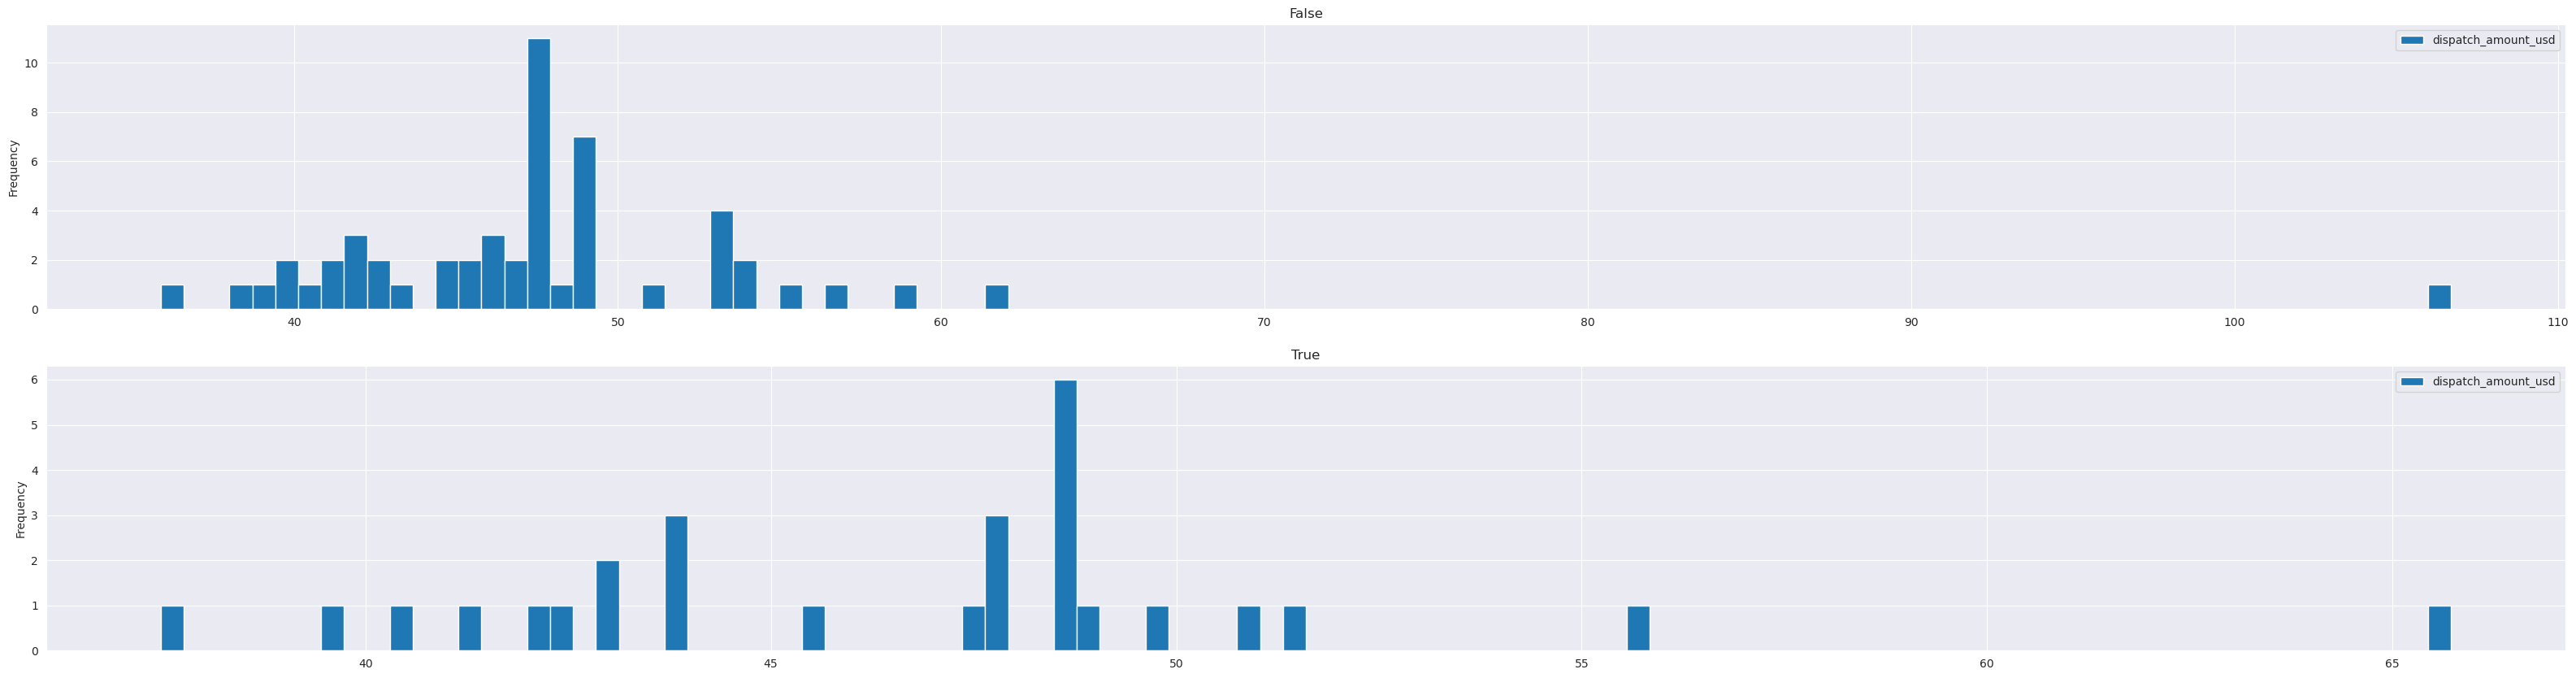

In [75]:
df_ride_deduplication.plot.hist(bins=100, column=['dispatch_amount_usd'], by='peak_time', figsize=(40,10))

In [76]:
# df_ride_deduplication['dispatch_amount_usd'].median()


In [77]:
c0 = df_ride_deduplication['holiday'] == False 
c1 = df_ride_deduplication['dayofweek'] < 5 
c2 = df_ride_deduplication['peak_time'] == False
c3 = df_ride_deduplication['nighttime'] == False
df_ride_base = df_ride_deduplication[c0 & c1 & c2 & c3] 
df_ride_base

,ride_id,level_1,index,dispatch_id,from_datetime,from_timezone_str,ride_inserted_at,dispatch_inserted_at,start_ltt_lp,start_lng_lp,...,weekday,dayofweek,country_alpha_2,country_subdiv,holiday,peak_time,nighttime,cost,profit,profit_rate
8,2535065,130,13106,794913,2023-04-11 11:50:00,Australia/Melbourne,2023-04-06 08:23:31.000000,2023-04-10 09:43:39.000000,-37.66900,144.83880,...,Tuesday,1,AU,SA,False,False,False,76.773711,-29.153711,-0.379736
13,2561362,94,12065,910463,2023-05-23 14:40:00,Australia/Melbourne,2023-04-28 04:31:22.000000,2023-05-22 02:06:53.000000,-37.66900,144.83880,...,Tuesday,1,AU,SA,False,False,False,39.979903,3.740097,0.093549
23,2569567,40,10484,859113,2023-05-05 20:50:00,Australia/Melbourne,2023-05-03 22:53:02.000000,2023-05-03 22:53:02.000000,-37.66900,144.83880,...,Friday,4,AU,SA,False,False,False,46.712725,1.287275,0.027557
25,2621437,12,9287,965410,2023-07-06 10:00:00,Australia/Melbourne,2023-06-08 15:03:13.000000,2023-06-08 15:03:13.000000,-37.66901,144.84103,...,Thursday,3,AU,SA,False,False,False,40.032773,13.367227,0.333907
27,2656073,36,10413,1038215,2024-02-15 11:25:00,Australia/Melbourne,2023-06-30 06:00:02.000000,2023-06-30 06:00:02.000000,-37.66900,144.83880,...,Thursday,3,AU,SA,False,False,False,46.024986,5.075014,0.110266
29,2697568,180,14676,1114272,2023-07-25 09:30:00,Australian Eastern Standard Time,2023-07-18 03:14:37.000000,2023-07-18 03:14:37.000000,-37.66882,144.85146,...,Tuesday,1,AU,SA,False,False,False,47.496655,0.223345,0.004702
39,2731182,31,10158,1176026,2023-08-04 19:20:00,Australia/Melbourne,2023-08-01 03:32:42.000000,2023-08-01 05:17:53.000000,-37.66900,144.83880,...,Friday,4,AU,SA,False,False,False,40.158815,7.561185,0.188282
43,2753810,67,11128,1223598,2023-08-14 14:20:00,Australia/Melbourne,2023-08-13 02:05:44.000000,2023-08-13 02:05:44.000000,-37.66900,144.83880,...,Monday,0,AU,SA,False,False,False,42.255810,5.464190,0.129312
47,2786467,118,12727,1295083,2023-09-05 11:30:00,Australia/Melbourne,2023-08-31 00:05:23.000000,2023-08-31 11:03:41.000000,-37.66900,144.83880,...,Tuesday,1,AU,SA,False,False,False,42.049506,-0.199506,-0.004745
49,2804236,44,10573,1329131,2023-10-12 10:30:00,Australia/Melbourne,2023-09-08 02:59:41.000000,2023-09-08 02:59:41.000000,-37.66900,144.83880,...,Thursday,3,AU,SA,False,False,False,38.547603,2.872397,0.074516


In [80]:
cost_median = df_ride_base['cost'].median()
idx = (df_ride_base['cost'] - cost_median).abs().idxmin()
idx

np.int64(126)

In [84]:
cost_profit = df_ride_base.loc[idx,'profit']
partner_id = df_ride_base.loc[idx,'partner_id']
(cost_median, cost_profit,partner_id)

(np.float64(42.476719490279365), np.float64(6.143280509720633), np.int64(2))

<Axes: ylabel='Frequency'>

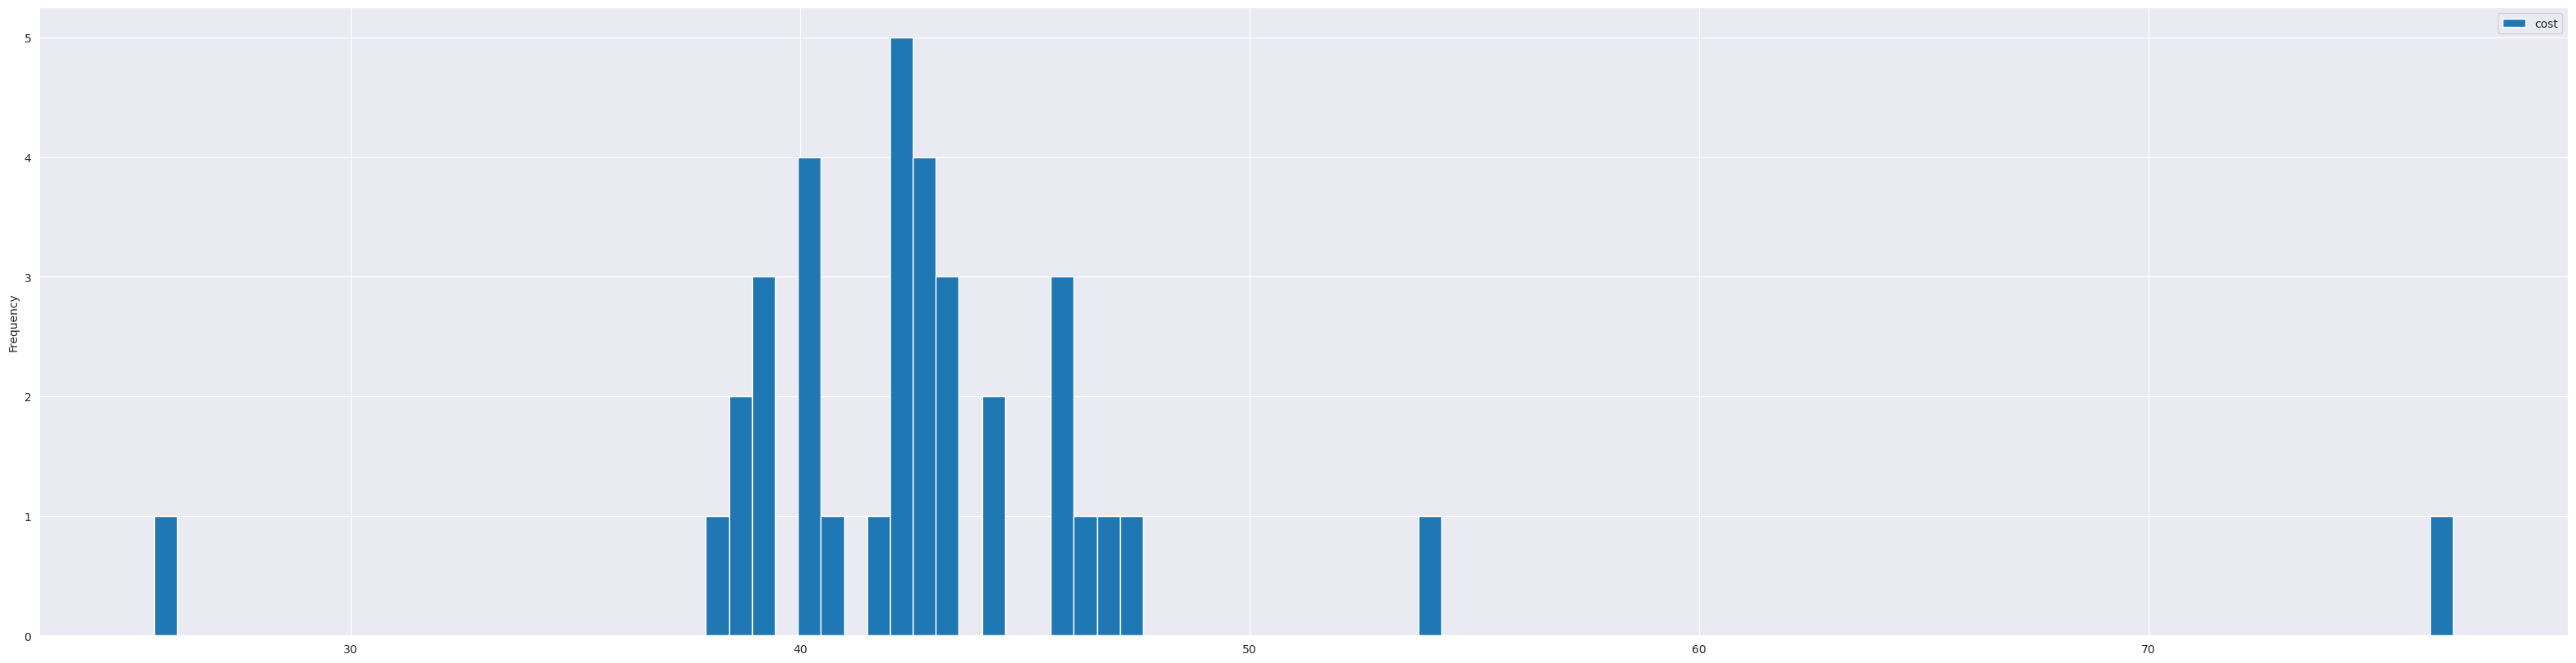

In [45]:
df_ride_base.plot.hist(bins=100, column=['cost'], figsize=(40,10))

In [343]:
# query_input.loc[['route_start','route_end','dispatch_amount','partner_id','vehicle_class_id','service_area_id','trip_count','trip_no']]

route_start         Ushuaia
route_end               USH
dispatch_amount       14.85
partner_id                3
vehicle_class_id        1.0
service_area_id         895
trip_count              1.0
trip_no                -1.0
Name: 1773656, dtype: object

<Axes: ylabel='Frequency'>

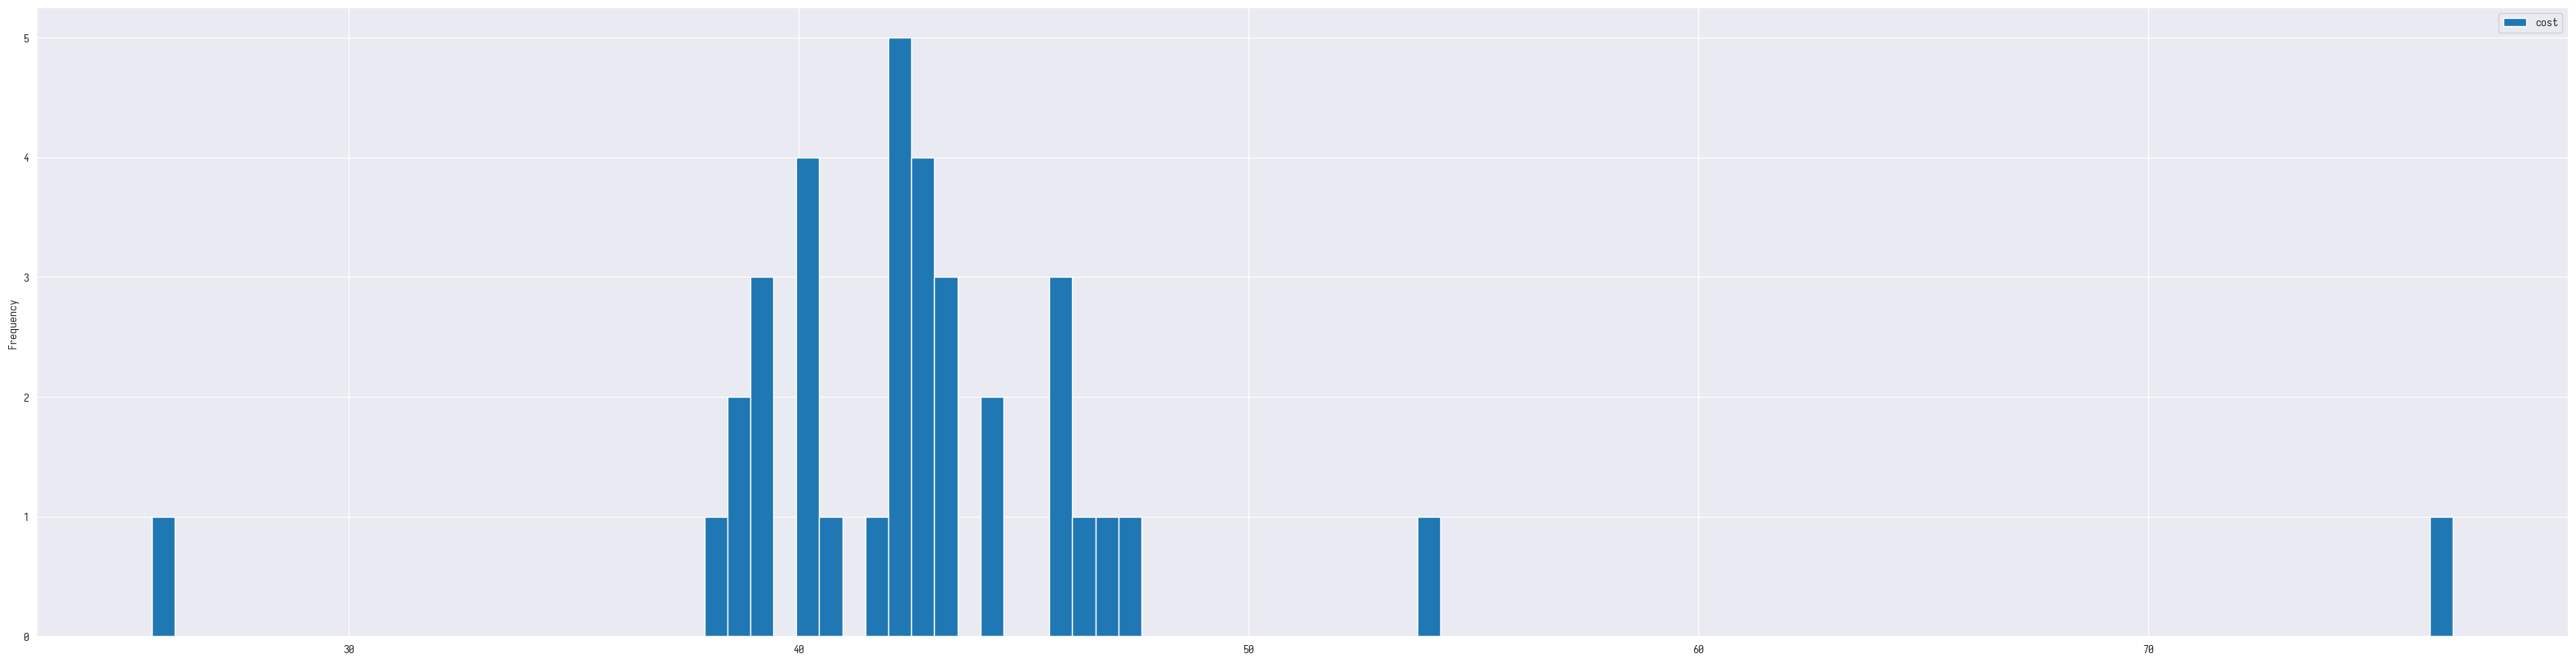

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
cost_dist = df_ride_base['cost']

plt.rcParams['font.family'] = ['Sarasa Term SC Nerd']
plt.rcParams['axes.unicode_minus']=False
df_ride_base.plot.hist(bins=100, column=['cost'], figsize=(40,10))

<Axes: ylabel='Frequency'>

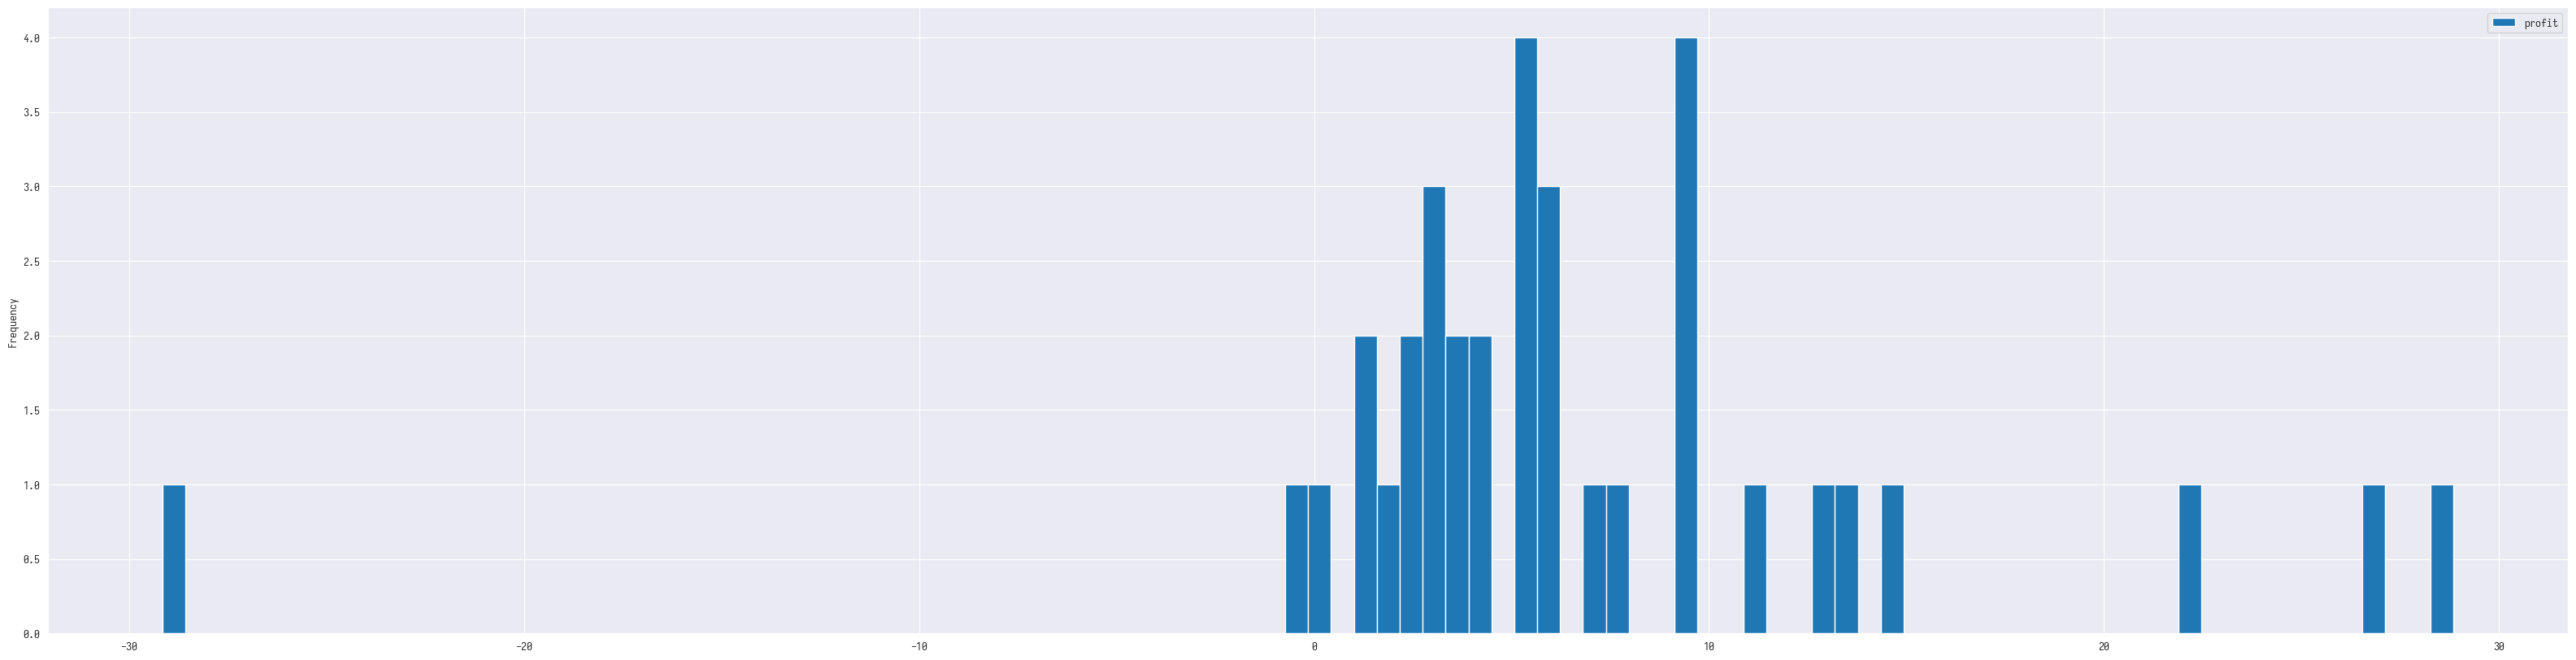

In [53]:
df_ride_base.plot.hist(bins=100, column=['profit'], figsize=(40,10))

In [13]:
import pycountry
import pgeocode
import warnings
import country_converter as coco
from geopy.geocoders import Nominatim
import holidays
from datetime import datetime
warnings.filterwarnings("ignore", message="The Argentina data file contains 4-digit postal codes which were replaced with a new system in 1999.")
warnings.filterwarnings("ignore", message="This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.")
pd.set_option('future.no_silent_downcasting', True)
p0 = datetime.strptime('07:00:00', '%H:%M:%S').time()
p1 = datetime.strptime('09:00:00', '%H:%M:%S').time()
p2 = datetime.strptime('16:00:00', '%H:%M:%S').time()
p3 = datetime.strptime('19:00:00', '%H:%M:%S').time()
n0 = datetime.strptime('22:00:00', '%H:%M:%S').time()
n1 = datetime.strptime('06:00:00', '%H:%M:%S').time()
peak_time_str = [(p0, p1), (p2, p3)]
night_time_str = [(n0, n1)] # Shanghai, US usually no overtime extra fees New York 8pm ~ 6am

subdv_code = ('','')
local_holidays = None

def get_state_code(country_name,city_name):
    # cn=coco.convert(country_name, to='name_short')
    cntry = pycountry.countries.search_fuzzy(country_name)[0]
    nomi = pgeocode.Nominatim(cntry.alpha_2)
    df_nomi = nomi.query_location(city_name, top_k=30, fuzzy_threshold=70, col='place_name')
    # df_nomi = df_nomi[city_name.lower() == df_nomi['place_name'].apply(lambda x: x.lower())]
    if df_nomi.empty:
        return None

    # r0 = df_nomi[['country_code', 'place_name', 'state_code', 'county_code']].iloc[0]
    state_code = df_nomi['state_code'].iloc[0]
    return state_code

def get_country_and_state_codes_from_geocoord(latitude, longitude):
    geolocator = Nominatim(user_agent="geocodequery")
    location = geolocator.reverse((latitude, longitude), exactly_one=True)

    if location:
        address = location.raw['address']
        country_code = address.get('country_code', None)
        state_code = address.get('state_code', None)

        return (country_code.upper(), state_code)

    return (None, None)

def feature_extraction(x):
    global subdv_code, local_holidays
    x.loc['dispatch_amount_usd'] = x['dispatch_amount'] / x['rate']
    x.loc['weekday'] = x['from_datetime'].day_name()
    x.loc['dayofweek'] = x['from_datetime'].weekday()
    x.loc['country_alpha_2'] = subdv_code[0]
    x.loc['country_subdiv'] = subdv_code[1]
    x.loc['holiday'] = x['from_datetime'] in local_holidays
    t = x['from_datetime'].time()
    x.loc['peak_time'] = p0 < t < p1 or p2 < t < p3
    x.loc['nighttime'] = n0 < t or t < n1
    return x

def cost_profit_extraction(x):
    cost = x[x['trip_no']>=0]['dispatch_amount_usd'].mean()
    x['cost'] = cost
    profit = x[x['trip_no']==-1]['dispatch_amount_usd'].mean()/x['trip_count'].mean() - cost
    x['profit'] = profit 
    # x['profit_rate'] = profit/ cost 
    
    return x

def cost_prediction(service_area_id, route_from_zone, route_to_zone, vehicle_class_id, update_flag=False):
    global fpz_lut_t
    global fpz_query_t
    global subdv_code
    global local_holidays

    if update_flag == False:
        cache_hit_t = (
            select(fpz_query_t)
            .where(
                and_(
                    fpz_query_t.c.start == route_from_zone,
                    fpz_query_t.c.end == route_to_zone,
                    fpz_query_t.c.service_area_id == int(service_area_id),
                    fpz_query_t.c.vehicle_class_id == int(vehicle_class_id),
                )
            )
            .select_from(fpz_query_t)
        )
        rp = gbq_conn.execute(cache_hit_t)
        results = rp.fetchall()
        if len(results) > 0:
            # prediction = (results[0]['cost'], results[0]['profit'])
            cost, profit = (results[0][3],results[0][4])
            cost = f"{cost:,.2f}"
            profit = f"{profit:,.2f}"
            prediction = (cost, profit)
            return prediction
        else:
            print("No cache hit")
            
    route_hist_dispatches = (
        select(fpz_lut_t)
        .where(
            and_(
                fpz_lut_t.c.route_start == route_from_zone,
                fpz_lut_t.c.route_end == route_to_zone,
                fpz_lut_t.c.service_area_id == int(service_area_id),
                fpz_lut_t.c.vehicle_class_id == int(vehicle_class_id),
                # fpz_lut_t.c.trip_no > -1,
            )
        )
        .select_from(fpz_lut_t)
    )

    # Execute the statement and fetch the results
    print("Executing query")
    df_query = pd.read_sql(route_hist_dispatches, gbq_eng)
    print("Query executed")
    assert df_query.shape[0] != 0, "No data available for prediction"

    df_query = df_query.astype({
        'from_datetime_fix_str': 'datetime64[ms]',
        'vehicle_class_id': 'int64',
        'passenger_count': 'int64',
        'trip_count': 'int64',
        'trip_no': 'int64',
    })
    df_query.rename(columns={'from_datetime_fix_str': 'from_datetime'}, inplace=True)
    df_query = df_query.drop_duplicates(subset='dispatch_id', keep='first')

    cntry_name = df_query['service_area'][0].rsplit(',',1)[-1].lstrip()
    cntry_name = coco.convert(cntry_name, to='name_short')
    cntry_obj = pycountry.countries.search_fuzzy(cntry_name)[0]
    country_code = cntry_obj.alpha_2
    cty_name = df_query['service_area'][0].rsplit(',',2)[-2].lstrip()
    state_code = get_state_code(cntry_name,cty_name)

    try:
        local_holidays = holidays.country_holidays(country=country_code, subdiv=state_code, years=2024)
    except NotImplementedError:
        print(f'No holidays for this subdivision of the country {subdv_code[0]}')
        local_holidays = holidays.country_holidays(cntry_obj.alpha_2, years=2024)
    
    df_query = df_query.apply(feature_extraction, axis=1)
    df_valid_samples = (df_query.groupby('ride_id').apply(cost_profit_extraction, include_groups=False)
                        .dropna(subset=['cost','profit','profit_rate'], how='any'))
    df_valid_samples = df_valid_samples.reset_index().drop_duplicates(subset=['ride_id'],keep='first')

    c_0 = df_valid_samples ['holiday'] == False
    c_1 = df_valid_samples ['dayofweek'] < 5
    c_2 = df_valid_samples ['peak_time'] == False
    c_3 = df_valid_samples ['nighttime'] == False
    df_valid_samples = df_valid_samples [c_0 & c_1 & c_2 & c_3]
    assert df_valid_samples.shape[0] != 0, "No data available for prediction"
    cost = float(df_valid_samples['cost'].median())
    idx = (df_valid_samples['cost'] - cost).abs().idxmin()
    profit = float(df_valid_samples.loc[idx,'profit'])
    ptnr_id = int(df_valid_samples.loc[idx,'partner_id'])

    df_fpz_route = pd.DataFrame([{
        "start": route_from_zone,
        "end": route_to_zone,
        "partner_id": ptnr_id,
        "cost": cost,
        "profit": profit,
        "service_area_id": int(service_area_id),
        "vehicle_class_id": int(vehicle_class_id),
    }])
    pandas_gbq.to_gbq(df_fpz_route, 
                      "price.fixed_zone_routes", 
                      project_id="elife-data-warehouse-test", 
                      if_exists="replace")
        
    
    cost = f"{cost:,.2f}"
    profit = f"{profit:,.2f}"
    prediction = (cost, profit)
    
    return prediction

# service_area_id, route_from_zone, route_to_zone, vehicle_class_id = 133, 'European Side,İstanbul', 'IST', 3
# predicted_cost = cost_prediction(service_area_id,
#                                  route_from_zone,
#                                  route_to_zone,
#                                  vehicle_class_id,
#                                  update_flag=True)
# 
# predicted_cost



In [14]:

from concurrent.futures import ThreadPoolExecutor, as_completed
import httpx
from http import HTTPStatus
from concurrent import futures
from enum import Enum
import numpy as np
import country_converter as coco
import pycountry
import pgeocode
from geopy.geocoders import Nominatim
import holidays
import warnings

In [15]:
sql_eng2 = create_engine('sqlite:///../data/price_2324.db', echo=False)
sql_conn2 = sql_eng2.connect()
sql_metadata2 = MetaData()
Sql_Session2 = sessionmaker(bind=sql_eng2)
sql_session2 = Sql_Session2()

routes_t = Table('routes_vehicle_class_2324', sql_metadata2, autoload_with=sql_eng2)
total_rows = sql_session.query(routes_t).count()
print(total_rows)

19482


In [16]:
df_routes_vehicle_class = pd.read_sql(select(routes_t), sql_conn)
df_routes_vehicle_class.shape

(19482, 59)

In [17]:
# df_routes_vehicle_class.to_sql('routes_vehicle_class_2324', sql_eng2, if_exists='replace', index=False)

In [18]:
service_areas_2324_fix_t = Table('service_areas_2324_fix', sql_metadata2, autoload_with=sql_eng2)
df_service_areas_fix = pd.read_sql(select(service_areas_2324_fix_t), sql_conn2, index_col='service_area_id')
df_service_areas_fix


,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,dispatch_id,index,ride_id,trip_count,from_utc,from_time_str,...,end_ltt,vehicle_class_id,vehicle_class,row_num,route_start,route_end,cost,profit,service_area_fix,holidays
service_area_id,,,,,,,,,,,,,,,,,,,,,
55,49.19669,-123.18151,49.28247,-123.11861,87749,183908,2206773,1,1.693854e+09,2023-09-04 12:00,...,49.282469,1.0,Sedan,1,YVR,Vancouver,None,None,"Vancouver,Canada",11
99,29.65561,-95.27792,29.30810,-94.79726,101558,52498,2213222,1,1.702665e+09,2023-12-15 12:30,...,29.308097,3.0,MPV-5,1,HOU,"Galveston, TX",None,None,"Houston,USA",13
38,37.61487,-122.38985,37.79414,-122.40779,123241,128980,2222284,1,1.740210e+09,2025-02-21 23:45,...,37.794138,1.0,Sedan,1,SFO,san francisco,None,None,"San Francisco, USA",14
165,19.43608,-99.07191,19.28447,-99.14919,140298,68154,2230107,1,1.682032e+09,2023-04-20 17:00,...,19.284467,1.0,Sedan,1,MEX,Mexico city south,None,None,"Mexico City,Mexico",8
40,40.75203,-73.98472,40.64131,-73.77814,155022,84728,2238054,1,1.672850e+09,2023-01-04 11:30,...,40.641311,6.0,MPV-4,1,曼哈顿,JFK,None,None,"New York,USA",10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5526,51.97723,7.61082,52.13460,7.68483,2705826,113316,3486413,1,1.722760e+09,2024-08-04 10:35,...,52.134602,1.0,Sedan,1,Münster,FMO,None,None,"Greven, Germany",9
1158,54.08330,-4.62389,54.18296,-4.47545,2774762,115116,3512920,1,1.717832e+09,2024-06-08 08:30,...,54.182957,1.0,Sedan,1,IOM,Douglas,None,None,Isle of Man,10
1419,46.62088,14.30649,46.65001,14.32486,2779550,102324,3520706,1,1.718618e+09,2024-06-17 12:00,...,46.650013,6.0,MPV-4,1,Klagenfurt,KLU,None,None,"Klagenfurt,Austria",13


In [19]:
dispatch_routes_t = Table('dispatch_feature_routes_2324_sa_fix', sql_metadata2, autoload_with=sql_eng2)
total_rows = sql_session2.query(dispatch_routes_t).count()
print(total_rows)

1061218


In [36]:

df_dispatch_routes = pd.read_sql(select(dispatch_routes_t), sql_conn2, index_col='dispatch_id')  #sqlite3
df_dispatch_routes

,index,from_datetime_fix_str,from_timezone_str,ride_inserted_at,dispatch_inserted_at,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,ride_id,...,passenger_count,luggage_count,children_count,infant_count,distance,duration,route_start,route_end,service_area_fix,holidays
dispatch_id,,,,,,,,,,,,,,,,,,,,,
1845170,0,2023-12-28 13:30:00,America/Argentina/Ushuaia,2023-12-18 16:52:11.000000,2023-12-18 16:52:11.000000,-54.8433,-68.2958,-54.80739,-68.30829,3064977,...,2.0,3.0,NaN,NaN,5989.0,751.0,USH,Ushuaia,"Ushuaia,Argentina",19
1717512,1,2024-03-02 11:25:00,America/Argentina/Ushuaia,2023-11-25 01:17:33.000000,2023-11-25 01:17:33.000000,-54.8433,-68.2958,-54.80724,-68.30465,3002859,...,2.0,3.0,NaN,NaN,6302.0,747.0,USH,Ushuaia,"Ushuaia,Argentina",19
2882892,2,2024-08-01 12:00:00,America/Argentina/Ushuaia,2024-03-30 12:35:43.000000,2024-07-01 15:00:22.000000,-54.8433,-68.2958,-54.80733,-68.30539,3363605,...,3.0,3.0,NaN,NaN,6350.0,772.0,USH,Ushuaia,"Ushuaia,Argentina",19
2029084,3,2024-07-24 21:25:00,America/Argentina/Ushuaia,2024-01-22 00:00:29.000000,2024-01-22 00:00:29.000000,-54.8433,-68.2958,-54.80501,-68.30144,3159454,...,2.0,3.0,NaN,NaN,6540.0,841.0,USH,Ushuaia,"Ushuaia,Argentina",19
2484384,4,2024-05-12 10:40:00,Argentina Standard Time,2023-12-05 17:30:18.000000,2024-04-08 16:00:12.000000,-54.8433,-68.2958,-54.80932,-68.31662,3031625,...,2.0,3.0,0.0,0.0,5414.0,666.0,USH,Ushuaia,"Ushuaia,Argentina",19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1520967,1061288,2023-10-19 22:55:00,Europe/Oslo,2023-10-01 21:31:32.000000,2023-10-18 08:34:14.000000,69.6833,18.9189,69.64816,18.95722,2860188,...,1.0,3.0,NaN,NaN,4968.0,552.0,IVL,Nellim,"Tromso, Norway",12
1234482,1061289,2023-11-13 18:40:00,Europe/Oslo,2023-08-15 20:58:24.000000,2023-08-15 20:58:24.000000,69.6833,18.9189,69.64894,18.95969,2759268,...,2.0,4.0,NaN,NaN,5157.0,660.0,TOS,Tromso,"Tromso, Norway",12
1757195,1061290,2024-02-22 13:30:00,Europe/Oslo,2023-12-02 15:05:37.000000,2023-12-02 15:05:37.000000,69.6833,18.9189,69.64803,18.95366,3023087,...,2.0,3.0,NaN,NaN,4792.0,490.0,TOS,Tromso,"Tromso, Norway",12


In [37]:
query_input = df_dispatch_routes.iloc[10000,:]  # 1000
# query_input = df_dispatch_routes[df_dispatch_routes['service_area_id'] == 133].iloc[0,:]
# query_input[['start','end']]
# query_input.loc[['dispatch_id','start','end','dispatch_amount','partner_id','vehicle_class_id','service_area_id','trip_count','trip_no']]
query_input['route_start'], query_input['route_end'], query_input['dispatch_amount'], query_input['service_area_id'], query_input['vehicle_class_id']
ltt, lng = query_input['start_ltt_lp'], query_input['start_lng_lp']
ltt, lng



('MEL', 'St Kilda圣基尔达', np.float64(71.36), np.int64(140), np.float64(1.0))

(np.float64(-37.669), np.float64(144.8388))

In [38]:
# df = pd.read_sql(select(dispatch_routes_t),con=sql_conn2)
# df.head()
# df.shape

In [20]:

routes_t = Table('routes_vehicle_class_2324', sql_metadata2, autoload_with=sql_eng2)
total_rows = sql_session.query(routes_t).count()
print(total_rows)

pd.options.mode.copy_on_write = True
max_concurrent = 48
chunk_size=100
non_cp_count = 0
routes_q = select(routes_t)


19482


In [21]:
CostQueryStatus = Enum('CostQueryStatus', 'NoCountryCode NoStateCode NoHistorySamples Success')
cost_profit = {'cost': None, 'profit': None}
local_holidays = None

def country_and_state_codes_from_geocoord(latitude, longitude):
    geolocator = Nominatim(user_agent="geocodequery")
    location = geolocator.reverse((latitude, longitude), exactly_one=True)

    if location:
        address = location.raw['address']
        country_code = address.get('country_code', None)
        state_code = address.get('state_code', None)

        return (country_code.upper(), state_code)

    return (None, None)

# country_and_state_codes_from_geocoord(ltt, lng)

def feature_extract(x):
    global local_holidays
    x.loc['dispatch_amount_usd'] = x['dispatch_amount'] / x['rate']
    x.loc['weekday'] = x['from_datetime'].day_name()
    x.loc['dayofweek'] = x['from_datetime'].weekday()
    # x.loc['country_alpha_2'] = subdv_code[0]
    # x.loc['country_subdiv'] = subdv_code[1]
    if local_holidays:
        x.loc['holiday'] = x['from_datetime'] in local_holidays
    else:
        x.loc['holiday'] = False
    t = x['from_datetime'].time()
    x.loc['peak_time'] = p0 < t < p1 or p2 < t < p3
    x.loc['nighttime'] = n0 < t or t < n1
    return x

def cost_profit_extract(x):
    cost = x[x['trip_no']>=0]['dispatch_amount_usd'].mean()
    x['cost'] = cost
    profit = x[x['trip_no']==-1]['dispatch_amount_usd'].mean()/x['trip_count'].mean() - cost
    x['profit'] = profit
    # x['profit_rate'] = profit/ cost 

    return x

def cost_prediction_sql(service_area_id, route_from_zone, route_to_zone, vehicle_class_id) -> CostQueryStatus: 
    global cost_profit,local_holidays
    route_hist_dispatches = (
        select(dispatch_routes_t)
        .where(
            and_(
                dispatch_routes_t.c.route_start == route_from_zone,
                dispatch_routes_t.c.route_end == route_to_zone,
                dispatch_routes_t.c.service_area_id == int(service_area_id),
                dispatch_routes_t.c.vehicle_class_id == int(vehicle_class_id),
            )
        )
        .select_from(dispatch_routes_t)
    )
    
    # Execute the statement and fetch the results
    # print("Executing query")
    df_query = pd.read_sql(route_hist_dispatches, sql_eng2)
    # print("Query executed")
    if df_query.shape[0] == 0: # "No data available for prediction"
        return CostQueryStatus.NoHistorySamples
    
    df_query = df_query.astype({
        'from_datetime_fix_str': 'datetime64[ms]',
        'vehicle_class_id': 'int64',
        # 'passenger_count': 'int64',
        'trip_count': 'int64',
        'trip_no': 'int64',
    })
    df_query.rename(columns={'from_datetime_fix_str': 'from_datetime'}, inplace=True)
    df_query = df_query.drop_duplicates(subset='dispatch_id', keep='first')

    ltt_start = df_query['start_ltt_lp'][0]
    lng_start = df_query['start_lng_lp'][0]
    # country_code, state_code = country_and_state_codes_from_geocoord(ltt_start, lng_start)
    service_area_str = df_query['service_area_fix'][0]
    comma_counts = service_area_str.count(',')
    # print(service_area_str)

    match comma_counts:
        case 0:
            try:
                cntry_name = service_area_str
                cntry_name = coco.convert(cntry_name, to='short_name')
                if cntry_name == 'not found':
                    return CostQueryStatus.NoCountryCode
                cntry_obj = pycountry.countries.search_fuzzy(cntry_name)[0]
                state_code = None
            except Exception as exc:
                return CostQueryStatus.NoCountryCode
        case 1:
            try:
                cntry_name = service_area_str.rsplit(',',1)[-1].lstrip()
                if cntry_name != "Virgin Islands of the United States":
                    cntry_name = coco.convert(cntry_name, to='short_name')
                    if cntry_name == 'not found':
                        return CostQueryStatus.NoCountryCode
                city_name = service_area_str.rsplit(',',2)[-2].lstrip()
                cntry_obj = pycountry.countries.search_fuzzy(cntry_name)[0]
                try:
                    nomi = pgeocode.Nominatim(cntry_obj.alpha_2)
                    df_nomi = nomi.query_location(city_name, top_k=30, fuzzy_threshold=70, col='place_name')
                    if df_nomi.empty:
                        state_code = None
                    else:
                        state_code = df_nomi['state_code'].iloc[0]
                except ValueError:
                    state_code = None
            except Exception as exc:
                return CostQueryStatus.NoCountryCode
        case 2:
            try:
                cntry_name = service_area_str.rsplit(',',1)[-1].lstrip()
                cntry_name = coco.convert(cntry_name, to='short_name')
                if cntry_name == 'not found':
                    return CostQueryStatus.NoCountryCode
                state_code = service_area_str.rsplit(',',2)[-2].lstrip()
                city_name = service_area_str.rsplit(',',3)[-3].lstrip()
                cntry_obj = pycountry.countries.search_fuzzy(cntry_name)[0]
                if cntry_name != "USA":
                    try:
                        nomi = pgeocode.Nominatim(cntry_obj.alpha_2)
                        df_nomi = nomi.query_location(city_name, top_k=30, fuzzy_threshold=70, col='place_name')
                        if df_nomi.empty:
                            state_code = None
                        else:
                            if state_code == df_nomi['state_code'].iloc[0]:
                                state_code = df_nomi['state_code'].iloc[0]
                            else:
                                state_code = None
                    except ValueError:
                        state_code = None
            except Exception as exc:
                return CostQueryStatus.NoCountryCode
        case _:
            return CostQueryStatus.NoCountryCode

    if state_code == None:
        try:
            local_holidays = holidays.country_holidays(cntry_obj.alpha_2, years=2024)
        except Exception as exc:
            local_holidays = None
    else:
        try:
            local_holidays = holidays.country_holidays(cntry_obj.alpha_2, subdiv=state_code,years=2024)
        except NotImplementedError:
            try:
                local_holidays = holidays.country_holidays(cntry_obj.alpha_2, years=2024)
            except Exception as exc:
                local_holidays = None

    df_query = df_query.apply(feature_extract, axis=1)
    df_valid_samples = (df_query.groupby('ride_id').apply(cost_profit_extract, include_groups=False)
                        .dropna(subset=['cost','profit'], how='any'))
    df_valid_samples = df_valid_samples.reset_index().drop_duplicates(subset=['ride_id'],keep='first')
    
    c_0 = df_valid_samples['holiday'] == False
    c_1 = df_valid_samples['dayofweek'] < 5
    c_2 = df_valid_samples['peak_time'] == False
    c_3 = df_valid_samples['nighttime'] == False
    df_valid_samples = df_valid_samples [c_0 & c_1 & c_2 & c_3]
    if df_valid_samples.shape[0] == 0: # "No data available for prediction"
        return CostQueryStatus.NoHistorySamples
    cost = float(df_valid_samples['cost'].median())
    idx = (df_valid_samples['cost'] - cost).abs().idxmin()
    profit = float(df_valid_samples.loc[idx,'profit'])
    # ptnr_id = int(df_valid_samples.loc[idx,'partner_id'])
   
    cost_profit['cost'] = cost
    cost_profit['profit'] = profit
    return CostQueryStatus.Success

# service_area_id, route_from_zone, route_to_zone, vehicle_class_id = 133, 'European Side,İstanbul', 'IST', 3
# status = cost_prediction_sql(service_area_id, route_from_zone, route_to_zone, vehicle_class_id)
# status
# cost_profit

for i,chunk in enumerate(tqdm(pd.read_sql(routes_q,sql_conn2,index_col='ride_inserted_at', chunksize=chunk_size),     total=total_rows//chunk_size+1, desc='Overall Progress')):
    # get_fixed_zone_chunk(chunk)

    chunk = chunk.dropna(subset=['service_area_id','route_start','route_end','vehicle_class_id'],how='any')
    non_cost_profit_count_chunk = chunk_size - chunk.shape[0]
    # with ThreadPoolExecutor(max_workers=max_concurrent) as executor:
    #     to_do_map = {} # list[futures.Future] = [] 
    #     for ind,r in tqdm(chunk.iterrows(),total=chunk_size,desc='chunk progress', leave=False):
    #     # for ind,r in chunk.iterrows():
    #         future = executor.submit(cost_prediction_sql, r['service_area_id'], r['route_start'], r['route_end'], r['vehicle_class_id'])
    #         to_do_map[future] = ind
    #     done_iter = as_completed(to_do_map)
    #     done_iter = tqdm(done_iter, total=len(to_do_map), desc='chunk progress', leave=False)
    # 
    #     for future in done_iter:
    #         try:
    #             status = future.result()
    #         except Exception as e:
    #             # print(f"Exception: {e}")
    #             continue
    # 
    #         if status == CostQueryStatus.Success:
    #             ind = to_do_map[future]
    #             try:
    #                 chunk.loc[ind, 'cost'] = cost_profit['cost']
    #                 chunk.loc[ind, 'profit'] = cost_profit['profit']
    #             except KeyError as e:
    #                 non_cost_profit_count_chunk += 1
    #                 # print(f"\r {e}: {non_cost_profit_count_chunk}/{chunk_size}")
    #                 continue
    #             except Exception as e:
    #                 non_cost_profit_count_chunk += 1
    #                 # print(f"\r {e}: {non_cost_profit_count_chunk}/{chunk_size}")
    #                 continue
    #         else:
    #             non_cost_profit_count_chunk += 1
    #             # print(f"\r non fzp chunk: {non_cost_profit_count_chunk}/{chunk_size}")
    #             continue
                
    for ind,r in tqdm(chunk.iterrows(),total=chunk_size,desc='chunk progress', leave=False):
        # for ind,r in chunk.iterrows():
        status = cost_prediction_sql(r['service_area_id'], r['route_start'], r['route_end'], r['vehicle_class_id'])

        if status == CostQueryStatus.Success:
            try:
                # print(f"{r['service_area_id']}, {r['route_start']}, {r['route_end']}, {r['vehicle_class_id']}: {cost_profit}")
                chunk.loc[ind, 'cost'] = cost_profit['cost']
                chunk.loc[ind, 'profit'] = cost_profit['profit']
            except KeyError as exc:
                non_cost_profit_count_chunk += 1
                # print(f"\r {exc}: {non_cost_profit_count_chunk}/{chunk_size}")
                continue
            except Exception as exc:
                non_cost_profit_count_chunk += 1
                # print(f"\r {exc}: {non_cost_profit_count_chunk}/{chunk_size}")
                continue
        else:
            non_cost_profit_count_chunk += 1
            # print(f"\r non fzp chunk: {non_cost_profit_count_chunk}/{chunk_size}")
            continue
            
    non_cp_count += non_cost_profit_count_chunk
    scanned_row_number = (i+1)*chunk_size
    try:
        # pd.DataFrame(data=route_list, columns=['dispatch_id', 'route_start', 'route_end']).to_csv(result_csv,     mode='a', header=False)
        with open('../data/routes_vehicle_class_2324.csv', 'a') as f:
            chunk.to_csv(f, header=f.tell()==0,chunksize=chunk_size)
        # chunk.to_csv(path_or_buf=csv_result_file_list[0],mode='a',chunksize=chunk_size)
        # chunk.to_sql(result_table[0], sql_eng, if_exists='append', index=True)
        print(f"\r Non_FZP count: {non_cp_count}/{scanned_row_number}")
    except Exception as e:
        print(f"\r {e}, Non_FZP count: {non_cp_count}/{scanned_row_number} ")
        continue


Overall Progress:   0%|          | 0/195 [00:00<?, ?it/s]

chunk progress:   0%|          | 0/100 [00:00<?, ?it/s]

 Non_FZP count: 11/100


chunk progress:   0%|          | 0/100 [00:00<?, ?it/s]

 Non_FZP count: 23/200


...

 Non_FZP count: 6847/19300


chunk progress:   0%|          | 0/100 [00:00<?, ?it/s]

 Non_FZP count: 6905/19400


chunk progress:   0%|          | 0/100 [00:00<?, ?it/s]

 Non_FZP count: 6972/19500


In [53]:
query_input = df_dispatch_routes.iloc[12000,:]  # 1000
service_area_id, route_from_zone, route_to_zone, vehicle_class_id = query_input.loc['service_area_id'], query_input.loc['route_start'], query_input.loc['route_end'], query_input.loc['vehicle_class_id']
service_area_id, route_from_zone, route_to_zone, vehicle_class_id

(np.int64(140), '南墨尔本', 'MEL', np.float64(1.0))

In [57]:
service_area_id, route_from_zone, route_to_zone, vehicle_class_id = 133, 'European Side,İstanbul', 'IST', 3
service_area_id, route_from_zone, route_to_zone, vehicle_class_id

(133, 'European Side,İstanbul', 'IST', 3)

In [59]:
predicted_cost = cost_prediction(service_area_id,
                                 route_from_zone,
                                 route_to_zone,
                                 vehicle_class_id)

predicted_cost


TypeError: unsupported format string passed to NoneType.__format__

In [89]:

predicted_cost

('39.18', '14.31')

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [55]:
routes_count = routes_dispatches['count']
routes_count = routes_count.apply(lambda x: np.log(x))

<Axes: xlabel='route_start,route_end'>

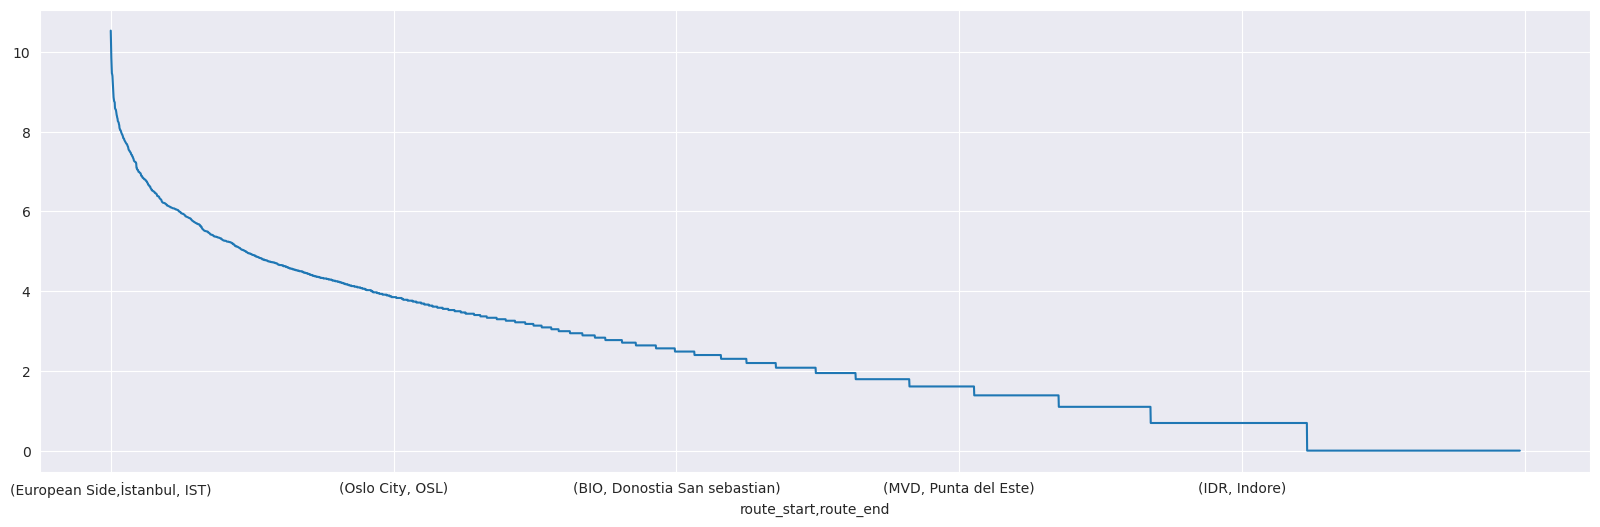

In [56]:
routes_count.plot(figsize=(20,6))
# routes_count


In [52]:
cumulative_count = routes_count.cumsum()
cumulative_count /= cumulative_count.iloc[-1]
cumulative_count = cumulative_count.apply(lambda x: np.log(x))

<Axes: xlabel='route_start,route_end'>

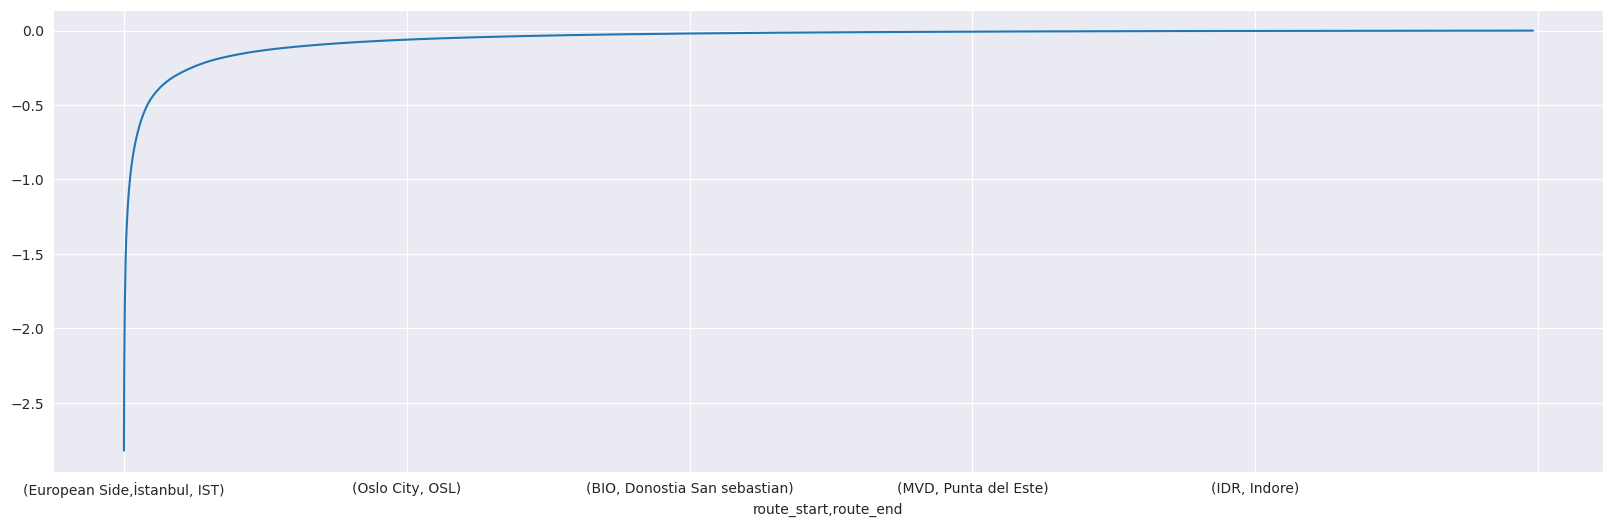

In [53]:

cumulative_count.plot(figsize=(20,6))

In [58]:
# df_routes = df.dropna(subset=['route_start', 'route_end'],how='all')
# len(df_routes)

631894

In [69]:
# # df_routes.set_index(['dispatch_id', 'route_end'], inplace=True)
# df_routes.iloc[:5,:]

,index,dispatch_id,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,route_start,route_end
0,0,2979402,-54.84330,-68.29580,-54.83495,-68.34771,USH,Ushuaia
1,1,2615870,-54.84330,-68.29580,-54.80621,-68.31104,USH,Ushuaia
2,2,2826367,-54.84330,-68.29580,-54.80621,-68.31104,USH,Ushuaia
3,3,1819243,-54.84330,-68.29580,-54.80264,-68.30629,USH,Ushuaia
4,4,2035026,-54.84330,-68.29580,-54.82094,-68.35159,USH,Ushuaia


In [23]:
# cols = df.columns
# cols

Index(['dispatch_id', 'start_ltt_lp', 'start_lng_lp', 'end_ltt_lp',
       'end_lng_lp', 'route_start', 'route_end'],
      dtype='object')

In [24]:

# cols = [c.name for c in query.subquery().columns]
# result = [dict(zip(cols, row)) for row in df.to_numpy()]
# # result = [row for row in df.to_numpy()]
# result

[{'dispatch_id': 2979402,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.83495',
  'end_lng_lp': '-68.34771',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id': 2615870,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.80621',
  'end_lng_lp': '-68.31104',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id': 2826367,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.80621',
  'end_lng_lp': '-68.31104',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id': 1819243,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.80264',
  'end_lng_lp': '-68.30629',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id': 2035026,
  'start_ltt_lp': '-54.84330',
  'start_lng_lp': '-68.29580',
  'end_ltt_lp': '-54.82094',
  'end_lng_lp': '-68.35159',
  'route_start': 'USH',
  'route_end': 'Ushuaia'},
 {'dispatch_id'

In [28]:

# from concurrent.futures import ThreadPoolExecutor, as_completed
# from concurrent import futures
# from enum import Enum
# 
# chunk_size = 1000
# non_fpz_count = 0
# max_concurrent = 24
# 
# connection2 = sql_eng.connect()


In [25]:
# query1000= query.limit(1000)
# chunk_size=100
# raw_total_rows = 1000
# # df = pd.read_sql(query1000, sql_eng)
# # df
# for i,chunk in enumerate(tqdm(pd.read_sql(query1000,connection,index_col='dispatch_id', chunksize=chunk_size), total=raw_total_rows//chunk_size+1, desc='Overall Progress')):
#     # for chunk in tqdm(pd.read_csv(csv_file_path, chunksize=chunk_size), total=total_lines//chunk_size +1):
#     # chunk.to_sql("price_training_labeled_2024_usd", sql_eng, if_exists='append', index=True)
#     dict_to_insert = [dict(zip(cols,row)) for row in chunk.to_numpy()]
#     insert_stmt = insert(label_archive).values(dict_to_insert)
#     session.execute(insert_stmt)
#     session.commit()



In [31]:
# FPZQueryStatus = Enum('FPZQueryStatus', 'JsonError KeyError DictError NoFixedPrice Success')
# fpz = {'route_start': None, 'route_end': None}
# def get_one_fpz(start_ltt_lp, start_lng_lp, end_ltt_lp, end_lng_lp) -> FPZQueryStatus:
#     global fpz, df_lut
#     idx = (start_ltt_lp, start_lng_lp, end_ltt_lp, end_lng_lp)
#     try:
#         fpz = dict(df_lut.loc[idx,['route_start', 'route_end']])
#     except KeyError as e:
#         fpz = {'route_start': None, 'route_end': None}
#         return FPZQueryStatus.KeyError
#     except Exception as exc:
#         raise exc
# 
#     return FPZQueryStatus.Success

# for i,chunk in enumerate(tqdm(pd.read_sql(query,connection,index_col='dispatch_id', chunksize=chunk_size), total=raw_total_rows//chunk_size+1, desc='Overall Progress')):
#     try:
#         # pd.DataFrame(data=route_list, columns=['dispatch_id', 'route_start', 'route_end']).to_csv(result_csv,     mode='a', header=False)
#         # if i<500:
#         #     file_path = "../data/price_training_labeled_2024_usd1.csv"       
#         # else:
#         #     file_path = "../data/price_training_labeled_2024_usd2.csv"
#         file_path = "../data/price_training_labeled_2024_usd.csv"
#         with open(file_path, 'a') as f:
#             # chunk.to_csv(f, header=f.tell()==0,chunksize=chunk_size)
#             chunk.to_sql(result_table[0], sql_eng, if_exists='append', index=True)
#     except Exception as e:
#         print(f"\r {e}")
#         continue

Overall Progress:   0%|          | 0/1063 [00:00<?, ?it/s]

In [208]:
# df1 = df_lut.iloc[:10,:]
# df1
# len(df1)
# idx = df1.index.drop_duplicates(keep='first')
# df1[~df1.index.duplicated(keep='first')]
# df1

,,,,dispatch_id,index,ride_id,trip_count,from_utc,from_time_str,from_timezone_str,to_time_str,to_timezone_str,passenger_count,...,start_ltt,end_place_id,end_place,end_lng,end_ltt,vehicle_class_id,vehicle_class,row_num,route_start,route_end
start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,,,,,,,,,,,,,,,,,,,,,
37.61487,-122.38985,37.79414,-122.40779,123241,89521,2222284,1.0,1.740210e+09,2025-02-21 23:45,Pacific Standard Time,None,None,2.0,...,37.614871,1868.0,旧金山唐人街 美国加利福尼亚州旧金山旧金山唐人街,-122.407791,37.794138,1.0,Sedan,1,SFO,san francisco
24.07630,-110.36712,24.15539,-110.32272,186130,57630,2252856,1.0,1.709903e+09,2024-03-08 06:00,Mexican Pacific Standard Time,None,None,1.0,...,24.076300,35735.0,Malecon La Paz,-110.322718,24.155387,1.0,Sedan,1,LAP,La Paz
13.91326,100.60420,13.75957,100.54034,204703,38293,2261809,1.0,1.709262e+09,2024-03-01 10:00,Indochina Time,None,None,2.0,...,13.913260,38357.0,"酒店 104/7 Thanon Rang Nam, Khwaeng Thanon Phaya...",100.540340,13.759571,1.0,Sedan,1,DMK,市区中心
-37.82128,144.96533,-37.66901,144.84103,225395,585,2271309,1.0,NaN,"Mar 31, 2022 8:0",None,None,None,NaN,...,-37.821275,186.0,Melbourne Airport,144.841027,-37.669012,NaN,None,1,南墨尔本,MEL
40.73546,140.69041,40.29349,140.59228,282225,57783,2297841,2.0,1.725052e+09,2024-08-31 06:04,Asia/Tokyo,2024-09-01 09:50,Asia/Tokyo,3.0,...,40.735459,2029269.0,"End Location,",140.592282,40.293487,5.0,Minibus-8,1,None,None
18.76775,98.96401,18.78225,98.98766,310988,45507,2309705,2.0,1.704533e+09,2024-01-06 16:30,Indochina Time,2024-01-11 06:25,Indochina Time,2.0,...,18.767749,1681.0,Phor Liang Meun Terracotta Arts Hotel โรงแรมพ่...,98.987665,18.782251,1.0,Sedan,1,CNX,9-古城
26.08507,-80.11666,25.79375,-80.27585,315058,62025,2311454,1.0,1.705151e+09,2024-01-13 08:00,Eastern Standard Time,None,None,8.0,...,26.085070,10670.0,"Aeropuerto Miami 5600 NW 36th St, Miami, FL 33...",-80.275851,25.793748,5.0,Minibus-8,1,Fort Lauderdale,MIA
31.19348,121.35203,31.14340,121.65787,338118,36941,2321366,1.0,1.713989e+09,2024-04-25 04:00,China Standard Time,None,None,2.0,...,31.193481,22027.0,"Shanghai Disneyland Park 4MV5+945, Pudong, Sha...",121.657871,31.143397,2.0,Business Sedan,1,SHA,浦东机场圈
-34.81500,-58.53483,-34.60368,-58.38156,340666,2855,2322479,1.0,1.722413e+09,2024-07-31 05:00,Argentina Standard Time,None,None,1.0,...,-34.815004,47780.0,Buenos Aires,-58.381559,-34.603684,1.0,Sedan,1,EZE,Microcentro


10

In [28]:
# # df1 = df_lut.iloc[:10,:]
# # df1
# # len(df1)
# # idx = df1.index.drop_duplicates(keep='first')
# # df1[~df1.index.duplicated(keep='first')]
# # df1
# route_t = Table('route_lp', metadata, autoload_with=sql_eng)
# route_t = select(route_t)
# # noinspection PyUnboundLocalVariable
# connection = sql_eng.connect()


In [29]:
# s = route_t.limit(10)
# df = pd.read_sql(s,sql_eng)
# df

,dispatch_id,start_ltt_lp,start_lng_lp,end_ltt_lp,end_lng_lp,route_start,route_end
0,2979402,-54.84330,-68.29580,-54.83495,-68.34771,,
1,2615870,-54.84330,-68.29580,-54.80621,-68.31104,,
2,2826367,-54.84330,-68.29580,-54.80621,-68.31104,,
3,1819243,-54.84330,-68.29580,-54.80264,-68.30629,,
4,2035026,-54.84330,-68.29580,-54.82094,-68.35159,,
5,2636003,-54.84330,-68.29580,-54.80900,-68.31558,,
6,2545121,-54.84330,-68.29580,-54.80740,-68.30604,,
7,1762309,-54.84330,-68.29580,-54.84171,-68.37298,,
8,2269213,-54.84330,-68.29580,-54.80733,-68.30539,,
9,2621659,-54.84330,-68.29580,-54.84183,-68.37259,,


In [30]:
# chunk_size = 10000

In [31]:
# from concurrent.futures import ThreadPoolExecutor, as_completed
# from concurrent import futures
# from enum import Enum

In [91]:
import json

# Create a dictionary with the data
data = {"cost": None, "profit": None}
data = {"cost": '30.09', "profit": '3.09'}

# Convert the dictionary to a JSON string
json_string = json.dumps(data)

# Format the JSON string using an f-string
formatted_string = f"User Data: {json_string}"

print(json_string)

{"cost": "30.09", "profit": "3.09"}


In [32]:
# csv_lp_route_result = '../data/lp_route_result.csv'


In [ ]:
# non_fpz_count = 0
# max_concurrent = 24
# FPZQueryStatus = Enum('FPZQueryStatus', 'JsonError KeyError DictError NoFixedPrice Success')
# fpz = {'route_start': None, 'route_end': None}
# def get_one_fpz(start_ltt_lp, start_lng_lp, end_ltt_lp, end_lng_lp) -> FPZQueryStatus:
#     global fpz, df_lut
#     idx = (start_ltt_lp, start_lng_lp, end_ltt_lp, end_lng_lp)
#     try:
#         fpz = dict(df_lut.loc[idx,['route_start', 'route_end']])
#     except KeyError as e:
#         fpz = {'route_start': None, 'route_end': None}
#         return FPZQueryStatus.KeyError
#     except Exception as exc:
#         raise exc
#     
#     return FPZQueryStatus.Success
# 
# for i,chunk in enumerate(tqdm(pd.read_sql(route_t,connection,index_col='dispatch_id', chunksize=chunk_size), total=total_rows//chunk_size+1, desc='Overall Progress')):
#     chunk = chunk.astype({'start_ltt_lp': float, 'start_lng_lp': float, 'end_ltt_lp': float, 'end_lng_lp': float, 'route_start': str, 'route_end': str})
#     non_fpz_count_chunk = 0
#     # get_fixed_zone_chunk(chunk)
#     # for ind,r in chunk.iterrows():
#     #     result = get_one_fpz(r['start_ltt_lp'], r['start_lng_lp'],r['end_ltt_lp'],r['end_lng_lp'])
#         
#     
#     with ThreadPoolExecutor(max_workers=max_concurrent) as executor:
#         to_do_map = {} # list[futures.Future] = [] 
#         # for ind,r in tqdm(chunk.iterrows(),total=chunk_size,desc='chunk progress', leave=False):
#         for ind,r in chunk.iterrows():
#             future = executor.submit(get_one_fpz, r['start_ltt_lp'], r['start_lng_lp'],r['end_ltt_lp'],r['end_lng_lp'])
#             to_do_map[future] = ind
#         done_iter = as_completed(to_do_map)
#         done_iter = tqdm(done_iter, total=len(to_do_map), desc='chunk progress', leave=False)
# 
#         for future in done_iter:
#             try:
#                 status = future.result()
#             except Exception as e:
#                 # print(f"Exception: {e}")
#                 continue
# 
#             if status == FPZQueryStatus.Success:
#                 ind = to_do_map[future]
#                 try:
#                     chunk.at[ind, 'route_start'] = fpz['route_start']
#                     chunk.at[ind, 'route_end'] = fpz['route_end']
#                 except KeyError as e:
#                     non_fpz_count_chunk += 1
#                     # print(f"\r {e}: {non_fzp_count_chunk}/{chunk_size}")
#                     continue
#                 except Exception as e:
#                     non_fpz_count_chunk += 1
#                     # print(f"\r {e}: {non_fzp_count_chunk}/{chunk_size}")
#                     continue
#             else:
#                 non_fpz_count_chunk += 1
#                 # print(f"\r non fzp chunk: {non_fzp_count_chunk}/{chunk_size}")
#                 continue
#         
#     non_fpz_count += non_fpz_count_chunk
#     scanned_row_number = (i+1)*chunk_size
#     try:
#         # pd.DataFrame(data=route_list, columns=['dispatch_id', 'route_start', 'route_end']).to_csv(result_csv,     mode='a', header=False)
#         with open(csv_lp_route_result, 'a') as f:
#             chunk.to_csv(f, header=f.tell()==0,chunksize=chunk_size)
#         # chunk.to_csv(path_or_buf=csv_result_file_list[0],mode='a',chunksize=chunk_size)
#         # chunk.to_sql(result_table[0], sql_eng, if_exists='append', index=True)
#         print(f"\r Non_FZP count: {non_fpz_count}/{scanned_row_number}")
#     except Exception as e:
#         print(f"\r {e}, Non_FZP count: {non_fpz_count}/{scanned_row_number} ")
#         continue

Overall Progress:   0%|          | 0/107 [00:00<?, ?it/s]

chunk progress:   0%|          | 0/10000 [00:00<?, ?it/s]

# inserted two new columns for fixed price zone start_zone and end_zone when creating sql table from csv file

In [ ]:
# # engine.execute('ALTER TABLE price_training_raw ADD COLUMN start_zone TEXT')
# # engine.execute('ALTER TABLE price_training_raw ADD COLUMN end_zone TEXT')
# start_zone_column = Column('start_zone', String)
# end_zone_column = Column('end_zone', String)
# add_column_op = AddColumn(start_zone_column, raw)


In [ ]:
# url = 'https://j1j495o5pk.execute-api.us-east-2.amazonaws.com/upncoming/ride-pricings'


In [ ]:
# # Query the table in chunks
# query = session.query(raw)
# chunk_size =1000

In [ ]:
# batch_stmt = (
#     update(raw)  # 'raw' is your table object
#     .where(raw.c.dispatch_id == bindparam('b_dispatch_id'))
#     .values(
#         route_start=bindparam('route_start'),
#         route_end=bindparam('route_end')
#     )
# )
# print(batch_stmt)
# compiled = batch_stmt.compile()
# print(compiled.params)


In [ ]:
# result_csv = '../data/dispatch_fixed_zones_all.csv'
# for chunk in tqdm(pd.read_sql(query.statement, conn, index_col='dispatch_id', chunksize=chunk_size), total=total_rows//chunk_size+1, desc='Overall Processing'):
#     # [chunk[r] for r in chunk]
#     # l = [r for r in chunk.iterrows()]
#     # l
#     # print(chunk.dtypes)
#     route_list = []
#     for i,r in tqdm(chunk.iterrows(),total=chunk_size, desc='Chunk Processing', leave=False):
#         # l = [i, r['start_ltt'], r['start_lng'], r['end_ltt'], r['end_lng']]
#         # print(l)
#         params = {
#             'from_lat': r['start_ltt'],
#             'from_lng': r['start_lng'],
#             'to_lat': r['end_ltt'],
#             'to_lng': r['end_lng'],
#         }
#         try:
#             response = requests.get(url=url, params=params)
#         except requests.exceptions.Timeout:
#             print('Timeout')
#             continue
#         except requests.exceptions.TooManyRedirects:
#             print('TooManyRedirects')
#             continue
#             # Tell the user their URL was bad and try a different one
#         except requests.exceptions.RequestException as e:
#             print('RequestException, Catastrophic error!')
#             continue
#             # catastrophic error. bail.
#             # raise SystemExit(e)
# 
#         except Exception as e:
#             print(f"request: {e}")
#             continue
#         # print('2')
#         try:
#             res = response.json()
#         except Exception as e:
#             print(f"json: {e}")
#             continue
#         # print('3')
#         try:
#             fix_price_zones = res['fleets'][0]['vehicle_classes'][0]['price_detail']['base_pricing']['fix_price_detail']
#         except KeyError as e:
#             print(f"No Fixed Price!")
#             continue
#         except IndexError as e:
#             print("IndexError for fix_price_zones")
#             continue
#         except Exception as e:
#             print(f"dict: {e}")
#             continue
#         # print('4')
#         if not isinstance(fix_price_zones,dict):
#             print(f"No fix price: {fix_price_zones}")
#         else:
#             try:
#                 route_list.append((i, fix_price_zones['from'], fix_price_zones['to']))
#                 # fix_zone_routes_list.append(route)
#                 # chunk.at[i, 'route_start'] = fix_price_zones['from']
#                 # chunk.at[i, 'route_end'] = fix_price_zones['to']
#                 # ins = insert(fixed_zone_routes).values(
#                 #     start=fix_price_zones['from'], end=fix_price_zones['from'], dispatch_id= pt        ._mapping['dispatch_id'])
#                 # stmt = (
#                 #     update(raw)  # 'raw' is your table object
#                 #     .where(raw.c.dispatch_id == int(i))
#                 #     .values(
#                 #         route_start = fix_price_zones['from'],
#                 #         route_end = fix_price_zones['to']
#                 #     )
#                 # )
#                 # conn.execute(stmt)
#                 # conn.commit()
#             except KeyError as e:
#                 print("KeyError for route")
#                 continue
#     
#     try:
#         pd.DataFrame(data=route_list, columns=['dispatch_id', 'route_start', 'route_end']).to_csv(result_csv, mode='a', header=False)
#     except Exception as e:
#         print(f"csv: {e}")
#         continue
#     
#     # with sqlite_eng.begin() as conn:
#     #     conn.execute(
#     #         stmt, 
#     #         [
#     #             {
#     #                 'b_dispatch_id': i,
#     #                 'route_start': r['route_start'],
#     #                 'route_end': r['route_end']
#     #             }
#     #             for i,r in chunk.iterrows()
#     #         ],
#     #     )
#     #     conn.commit()


In [ ]:
# len(result)
# result[0]

In [ ]:

# with sql_eng.begin() as conn:
#     conn.execute(
#         batch_stmt, 
#         [
#             {
#                 'b_dispatch_id': i,
#                 'route_start': r['route_start'],
#                 'route_end': r['route_end']
#             }
#             for i,r in res.iterrows()
#         ],
#     )
#     conn.commit()


In [ ]:
# for chunk in pd.read_sql(query.statement, local_conn, chunksize=20):
#     # [chunk[r] for r in chunk]
#     # l = [r for r in chunk.iterrows()]
#     # l
#     for i,r in chunk.iterrows():
#         # l = [r[0], r[1]['start_ltt'], r[1]['start_lng'], r[1]['end_ltt'], r[1]['end_lng']]
#         params = {
#             'from_lat': r['start_ltt'],
#             'from_lng': r['start_lng'],
#             'to_lat': r['end_ltt'],
#             'to_lng': r['end_lng'],
#         }
#         try:
#             response = requests.get(url=url, params=params)
#         except requests.exceptions.Timeout:
#             print('Timeout')
#             continue
#         except requests.exceptions.TooManyRedirects:
#             print('TooManyRedirects')
#             continue
#             # Tell the user their URL was bad and try a different one
#         except requests.exceptions.RequestException as e:
#             print('RequestException, Catastrophic error!')
#             continue
#             # catastrophic error. bail.
#             # raise SystemExit(e)
#         
#         except Exception as e:
#             print(f"request: {e}")
#             continue
#         # print('2')
#         try:
#             res = response.json()
#         except Exception as e:
#             print(f"json: {e}")
#             continue
#         # print('3')
#         try:
#             fix_price_zones = res['fleets'][0]['vehicle_classes'][0]['price_detail']['base_pricing']['fix_price_detail']
#         except KeyError as e:
#             j = j +1
#             print(f"{j} Not Fixed Price!")
#             continue
#         except IndexError as e:
#             print("IndexError for fix_price_zones")
#             continue
#         except Exception as e:
#             print(f"dict: {e}")
#             continue
#         # print('4')
#         if not isinstance(fix_price_zones,dict):
#             print(f"No fix price: {fix_price_zones}")
#         else:
#             try:
#                 # route = (fix_price_zones['from'], fix_price_zones['to'],pt._mapping['dispatch_id'])
#                 # fix_zone_routes_list.append(route)
#                 chunk.at[i, 'route_start']
#                 
#                 # ins = insert(fixed_zone_routes).values(
#                 #     start=fix_price_zones['from'], end=fix_price_zones['from'], dispatch_id= pt        ._mapping['dispatch_id'])
#                 i = i +1
#             except KeyError as e:
#                 print("KeyError for route")
#                 continue
#         
#         price_training_q = session.query(price_training_t).limit(500)
# fix_zone_routes_list = []


In [ ]:
# i = 0
# j = 0
# for pt in price_training_q:
#     # print('1')
#     # ride_samples.append(pt)
#     params = {
#         'from_lat': pt._mapping['start_ltt'],
#         'from_lng': pt._mapping['start_lng'],
#         'to_lat': pt._mapping['end_ltt'],
#         'to_lng': pt._mapping['end_lng'],
#         # 'from_utc':pt._mapping['from_utc'],
#     }
#     try:
#         response = requests.get(url=url, params=params)
#     except requests.exceptions.Timeout:
#         print('Timeout')
#         continue
#     except requests.exceptions.TooManyRedirects:
#         print('TooManyRedirects')
#         # Tell the user their URL was bad and try a different one
#     except requests.exceptions.RequestException as e:
#         print('RequestException, Catastrophic error!')
#         # continue
#         # catastrophic error. bail.
#         raise SystemExit(e)    
#         
#     except Exception as e:
#         print(f"request: {e}")
#         continue
#     # print('2')
#     try:
#         res = response.json()
#     except Exception as e:
#         print(f"json: {e}")
#         continue
#     # print('3')
#     try:
#         fix_price_zones = res['fleets'][0]['vehicle_classes'][0]['price_detail']['base_pricing']['fix_price_detail']
#     except KeyError as e:
#         j = j +1
#         print(f"{j} Not Fixed Price!")
#         continue
#     except IndexError as e:
#         print("IndexError for fix_price_zones")
#         continue
#     except Exception as e:
#         print(f"dict: {e}")
#         continue
#     # print('4')
#     if not isinstance(fix_price_zones,dict):
#         print(f"No fix price: {fix_price_zones}")
#     else:
#         try:
#             route = (fix_price_zones['from'], fix_price_zones['to'],pt._mapping['dispatch_id'])
#             fix_zone_routes_list.append(route)
#             # ins = insert(fixed_zone_routes).values(
#             #     start=fix_price_zones['from'], end=fix_price_zones['from'], dispatch_id= pt._mapping['dispatch_id'])
#             i = i +1
#         except KeyError as e:
#             print("KeyError for route")
#             continue
# 
#         # print('5')
#         if i%50 == 0:
#             # connection.execute(ins)
#             df = pd.DataFrame(fix_zone_routes_list, columns=['start', 'end', 'dispatch_id'])
#             df.to_sql('fixed_zone_routes', sqlite_eng, if_exists='append')
#             fix_zone_routes_list = []
#             print(f"Created {i} records")
# 
#     # print('6')
# df = pd.DataFrame(fix_zone_routes_list, columns=['start', 'end', 'dispatch_id'])
# df.to_sql('fixed_zone_routes', sqlite_eng, if_exists='append')
# fix_zone_routes_list = []
# print(f"Created {i} records")
#     # print('6')
#     # print(pt._mapping['ride_id'], pt._mapping['dispatch_amount'], pt._mapping['dispatch_currency'])
#     # # print(pt._mapping['start_place'])
#     # print(pt._mapping['start_lng'], pt._mapping['start_ltt'])
#     # # print(pt._mapping['end_place']) 
#     # print(pt._mapping['end_lng'], pt._mapping['end_ltt'])
#     # print("------------")

# Use ORM to retrieve records


In [ ]:
# sample_count = session.query(F.count(price_training_t.c.ride_id)).scalar()
# print(sample_count)
# 

In [ ]:
# url = 'https://j1j495o5pk.execute-api.us-east-2.amazonaws.com/upncoming/ride-pricings'

In [ ]:

# params = {
#     'from_lat': 37.61911449999999,
#     'from_lng':-122.3816274,
#     'to_lat':37.3635295,
#     'to_lng':-121.9285932,
#     'from_utc':1727352000,
# }
# response = requests.get(url=url, params=params)
# response.json()


In [ ]:
# res = response.json()
# fix_price_zones = res['fleets'][0]['vehicle_classes'][0]['price_detail']['base_pricing']['fix_price_detail']
# print(fix_price_zones)

In [ ]:
# ride_samples = []

In [ ]:
# pt = price_training_q.first()
# pt

In [ ]:
# params = {
#     'from_lat': (pt._mapping['start_ltt']),
#     'from_lng': (pt._mapping['start_lng']),
#     'to_lat': (pt._mapping['end_ltt']),
#     'to_lng': (pt._mapping['end_lng']),
#     # 'from_utc': int(pt._mapping['from_utc']),
# }
# params

# response = requests.get(url=url, params=params)
# res = response.json()
# res

In [ ]:
from sqlalchemy import String,Integer,insert

In [ ]:
# fix_zone_routes_list

In [ ]:
# price_training_q = session.query(price_training_t).limit(10)
# ride_samples = []
# for pt in price_training_q:
#     ride_samples.append(pt)
#     print(pt._mapping['ride_id'], pt._mapping['dispatch_amount'], pt._mapping['dispatch_currency'])
#     # print(pt._mapping['start_place'])
#     print(pt._mapping['start_lng'], pt._mapping['start_ltt'])
#     # print(pt._mapping['end_place']) 
#     print(pt._mapping['end_lng'], pt._mapping['end_ltt'])
#     print("------------")



In [ ]:
# ride_samples[0]._mapping

In [ ]:
# df = pd.DataFrame(ride_samples)
# df

In [ ]:

# rides_q = session.query(price_training_t).limit(10)

In [ ]:

# for ride in rides_q:
#     print(ride)

In [ ]:
# rides_q = session.query(ride_ride_t).limit(10)
# for ride in rides_q:
#     print(ride)

In [ ]:
# print(price_training_t)

In [ ]:
# use core to retrieve records
# rp = connection.execute(price_training_t)
# for i, record in enumerate(rp):
#     print(i, record.ride_id)

In [ ]:
# results = rp.fetchall()
# results

In [ ]:
# df = pd.read_sql(price_training_t, engine)
# df

In [ ]:
# sqlite_eng = create_engine('sqlite:///../data/price_training_from_gbq_raw.db', echo=False)

In [ ]:
# df.to_sql('price_training_orlando_mpv5', sqlite_eng, if_exists='replace')

# Pandas Processing


## Traffic peak time exclusion
source https://www.quora.com/What-is-the-trickiest-time-of-the-day-to-drive-in-Orlando

In [ ]:
# from workalendar.usa import Florida

In [ ]:
# cal_orlando = Florida()


In [ ]:
# exclude_dates = [d[0] for d in cal_orlando.holidays(2024)]
# exclude_dates

In [ ]:
# from workalendar.usa import Florida 
# import numpy as np
# cal_florida = Florida()
# exclude_dates_str = [str(d[0]) for d in cal_florida.holidays(2024)]
# exclude_dates_str

In [ ]:
# exclude_dates = [d[0] for d in cal_florida.holidays(2024)]
# exclude_dates
# res = df['from_datetime_utc'].apply(lambda x: x in exclude_dates)

In [ ]:
# np.any(res.apply(lambda x: x in exclude_dates))
# res[0]=True
# res
# np.any(res)


In [ ]:
# from pricing.data.utils import validate_datetime_in_iso_format, validate_timezone_in_iana, get_timezone_abbreviation, fix_timezone

In [ ]:
# df_invalid_datetime = df[df.apply(lambda x: not validate_datetime_in_iso_format(x['from_datetime_fix_str']), axis=1)]
# df_invalid_datetime

In [ ]:
# df_invalid_timezone = df[df.apply(lambda x: not validate_timezone_in_iana(x['from_timezone_str']), axis=1)]
# df_invalid_timezone

In [ ]:
#orlando_airport = pd.read_csv('../../data/orlando_all_output.csv')
#orlando_airport.head()
#orlando_airport.dtypes
#orlando_airport.to_sql('orlando_airport', sqlite_eng, if_exists='append')

In [ ]:
# df['from_timezone_fix_str'] = df.apply(lambda x: fix_timezone(x['from_timezone_str']), axis=1) 
# df

In [ ]:

# df_valid_datetime = df[df.apply(lambda x: validate_datetime_in_iso_format(x['from_datetime_fix_str']), axis=1)]
# df_valid_timezone = df_valid_datetime[df_valid_datetime.apply(lambda x: validate_timezone_in_iana(x['from_timezone_fix_str']), axis=1)]
# df_valid_timezone


In [ ]:

# df_valid_timezone.loc[df_invalid_timezone.index, ['from_timezone_str', 'from_timezone_fix_str']]


In [ ]:
# from datetime import datetime
# import pytz
# df_utc_offset = (df_valid_timezone.apply(lambda x: datetime.now(pytz.timezone(x['from_timezone_fix_str'])), axis=1)
#                             .apply(lambda x: x.strftime('%z')))
# df_utc_offset.name = 'utc_offset'
# df_utc_offset


In [ ]:
# df_dt_str = df_valid_timezone['from_datetime_fix_str']
# df_valid_timezone['from_datetime_local'] = df_valid_timezone.apply(lambda x: (pd.to_datetime(x['from_datetime_fix_str']).to_datetime64()), axis=1)
# df_valid_timezone

In [ ]:
# df_valid_timezone.dtypes

In [ ]:

# df_valid_timezone['from_datetime_local_tz'] = df_valid_timezone.apply(lambda x: pytz.timezone(x.loc[:,'from_timezone_str']).localize(x.loc[:,'from_datetime_local']), axis=1)
# df_valid_timezone['from_timezone'] = df_valid_timezone.apply(lambda x: pytz.timezone(x['from_timezone_fix_str']), axis=1)
# df_valid_timezone


In [ ]:
# df_valid_timezone['from_datetime_tz'] = df_valid_timezone.apply(lambda x: x['from_timezone'].localize(x['from_datetime_local']), axis=1)
# df_valid_timezone
                                    # .apply(lambda x: x.localize(x.loc[:,'from_timezone_str']), axis=1))
# df_valid_timezone


# filtering out peak traffic time

In [ ]:
# peak_time_str = [('07:00:00', '09:00:00'), ('16:00:00', '19:00:00')]
# night_time_str = [('22:00:00', '6:00:00')]  # Shanghai, US usually no overtime extra fees New York 8pm ~ 6am
# ind = []
# td = []
# for pt in peak_time_str:
#     ind.append(pd.DatetimeIndex(pt))
# ind
# for i in ind:
#     i[1]-i[0]

In [ ]:
# peak_time = []
# for pt in peak_time_str:
#     peak_time.append(pd.date_range(pt[0], pt[1], freq='h'))
# for pt in peak_time:
#     print(pt, pt.time)

In [ ]:
# peak_time_str

In [ ]:

# df_peak_traffic_time = df_valid_timezone[
#     df_valid_timezone['from_datetime_tz'].apply(lambda x: x.strftime('%H:%M:%S')).between(*peak_time_str[0])
#     | df_valid_timezone['from_datetime_tz'].apply(lambda x: x.strftime('%H:%M:%S')).between(*peak_time_str[1])
# ]
# df_peak_traffic_time

In [ ]:

# df_out_of_peak_traffic_time = df_valid_timezone[
#     ~ (df_valid_timezone['from_datetime_tz'].apply(lambda x: x.strftime('%H:%M:%S')).between(*peak_time_str[0])
#     | df_valid_timezone['from_datetime_tz'].apply(lambda x: x.strftime('%H:%M:%S')).between(*peak_time_str[1]))
# ]
# df_out_of_peak_traffic_time


In [ ]:

# df_utc_offset = (df_valid_timezone.apply(lambda x: datetime.now(pytz.timezone(x.loc['timezone'])))
#                             .apply(lambda x: x.strftime('%z')))
# df_utc_offset.name = 'utc_offset'
# df_utc_offset
# 

# filter out round trip (time reservation) with feature distance = 1 (m)

In [ ]:
# df_no_round_trip = df_valid_timezone[df_valid_timezone['distance'] > 1]

In [ ]:
# df_training = df_no_round_trip.loc[:,['ride_id', 'trip_type', 'trip_no', 'trip_count', 'ride_status', 'partner', 'fleet', 
#                 'start_place', 'end_place',
#                 'passenger_count', 'luggage_count',
#                 'dispatch_amount', 'dispatch_currency',
#                 'distance', 'duration', 'vehicle_class', 
#                 'from_datetime_tz']]
#  
# df_training['cent_price_per_km'] = df_training['dispatch_amount'] / df_training['distance']*100.0
# df_training

In [ ]:
# def average_cent_per_km(x):
#     x['average_cent_per_km'] = x['cent_price_per_km'].mean()
#     return x

In [ ]:
# def fleet_trip_no(x):
#     x['fleet_trip_count'] = len(x)
#     return x

In [ ]:
# df_fleet_statistics = df_training.loc[:, ['ride_id','fleet']]
# df_fleet_statistics

In [ ]:

# df_fleet_trip_no = df_fleet_statistics.groupby('fleet').aggregate([len])
# df_fleet_trip_no.sort_values(by=('ride_id', 'len'), ascending=False, inplace=True)
# df_fleet_trip_no


In [ ]:
# df_big_fleets = df_fleet_trip_no[df_fleet_trip_no[('ride_id','len')] >100]
# df_big_fleets

In [ ]:
# df_big_fleet_data = []
# for f in df_big_fleets.index:
#     print(f)
#     df_big_fleet_data.append(df_training[df_training['fleet'] == f])

In [ ]:
# df_big_fleet_data[0]

In [ ]:
# df_big_fleet_data[1]

In [ ]:
# df_big_fleet_data[2]

In [ ]:

# # df_training['average_cent_per_km'] = df_training.groupby('fleet').apply(average_cent_per_km)
# df_analysis = df_training.groupby('fleet').apply(average_cent_per_km)
# df_analysis


In [ ]:

# df_training

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()